# Sentiment Analysis and Change-Point Detection

**CS 1090B, Project Group #99**

Members (alphabetical by last name, not contribution order):

- Xuekun Huang
- Ghazal Jafari Naeimi
- Angkai Li
- Bruce Meng

---

Sec 8 scores each review's sentiment. Sec 9 turns those scores into product-level time series (monthly + weekly) and detects change points 4 different ways plus a hybrid. Sec 10 checks whether Sec 9's change points actually line up with 5 real-world smartphone events (using Hedges' g, a reverse-direction null, a multi-anchor bootstrap, and BH-FDR / Bonferroni-Holm correction).

**How to run**: drop the dataset at `./data/Cell_Phones_and_Accessories_5.json`, then *Restart Kernel + Run All*. Sec 0 handles missing deps. Caches go to `./cache/`, weights to `./models/`, tables and figures to `./outputs/` and `./figures/`. DeBERTa and Task 2 training are resume-aware - rerunning won't retrain, it just reads the cache.


# 0. Imports, Configuration, and Globals (Centralized)

Sec 0.1 + Sec 0.2 are the **single source of truth** for the pipeline:

- **Standard library + numerical/visualization imports**
- **sklearn** (Task 1 baseline + Task 2 evaluation)
- **Optional dependency probes**: VADER, transformers/peft/datasets, ruptures, claspy, momentfm, each guarded with `HAS_*` flags so missing optional packages don't break the notebook
- **Random seeds** (Python, NumPy, PyTorch, HF transformers), single seeding pass
- **Device detection** (`device`, `USE_CUDA`, `USE_BF16`, `USE_FP16`)
- **All paths** (raw + derived directories, cleaning cache, Task 2 panels)
- **All hyperparameters** (Task 1 cleaning + Task 2 filter/weighting/embedding/window/synthetic)
- **Atomic IO helpers** (`atomic_to_csv`, `atomic_to_pickle`, etc.)

In [1]:
# Sec 0.1 Environment setup - MUST run before any HF/transformers import.
# setup_environment() (a) sets HF mirror + cache env vars (b) idempotent pip install
# (c) hard-verifies peft / ruptures / momentfm. Disk check warns if < 10 GB free.
from src.config.env import setup_environment

setup_environment(install=True, verify=True, prewarm=False)

transformers>=4.49 installed; DeBERTa forced to fp32 (bf16 NaN'd at step 100, see env.py comment)
Verifying critical packages:
  ok  peft        version=0.19.1
  ok  ruptures    version=v1.1.10
  ok  momentfm    version=?

All required packages ready.
Disk space ok: 24.9 GB free in /Users/angkai/Desktop/1090/1090b-ms4


In [2]:
# Sec 0.2 Project paths + hyperparameters + runtime state.
# All path constants (CACHE_DIR, T1_*, T2_*, FIG_*) come from src.config.paths,
# which also auto-creates all directories under PROJECT_DIR on import.

from pathlib import Path
import json, pickle, time
from src.config import paths, hyperparams, runtime
from src.config.paths import *   # PROJECT_DIR, all T1_*, T2_*, FIG_*
from src.config.hyperparams import (
    RANDOM_STATE, SENTIMENT_MIN, SENTIMENT_MAX,
    MIN_REVIEWS_TASK2, MIN_OBS_PER_MONTH, MIN_OBS_PER_WEEK,
    EMBED_DIM, RARE_THRESHOLD_MONTHS, LAMBDA_L2, ALPHA, BETA,
    WINDOW_LEN_R2, WINDOW_LEN_R3, WINDOW_LEN_R4, R1_MIN_SIZE,
    R1_MIN_SERIES_MONTHS, R1_MIN_SERIES_WEEKS, N_SYNTHETIC, MOMENT_TARGET_LEN,
    CLEANING_VERSION,
)
from src.config.runtime import (
    device, USE_CUDA, USE_BF16, USE_FP16, CUDA_DEVICE_NAME,
    HAS_VADER, HAS_TRANSFORMERS, HAS_RUPTURES, HAS_CLASPY, HAS_MOMENT,
    set_all_seeds, print_status,
)
from src.utils.io import (
    atomic_to_csv, atomic_to_pickle, atomic_write_text,
    atomic_torch_save, atomic_savez, atomic_save_pretrained,
    read_json_or_none, raw_file_signature,
)
from src.utils.metrics import rmse, weighted_mean_with_fallback
from src.utils.format import format_elapsed
from src.utils.losses import FocalLoss
from src.utils.training import BestStateTracker, split_train_val, cleanup_gpu

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

set_all_seeds(RANDOM_STATE)
print(f"config loaded.")
print_status()
print(f"  Project dir:   {PROJECT_DIR}")

config loaded.
  Device:        CPU  (bf16=False, fp16=False)
  Random seed:   1090
  Optional deps: VADER=True  transformers=True  ruptures=True  claspy=True  moment=True
  Project dir:   /Users/angkai/Desktop/1090/1090b-ms4


# 1. Load Cell Phone Raw Data

Load the Amazon cell phone review JSON-lines file into `df_raw`.


In [3]:
# Sec 1 Load raw cell-phone reviews JSON-lines file.
from src.data.load import load_raw_if_needed, clean_cache_is_valid

if not CELL_PHONE_PATH.exists():
    raise FileNotFoundError(f"Missing data file: {CELL_PHONE_PATH}")

df_raw = load_raw_if_needed(CELL_PHONE_PATH)
if df_raw is None:
    print(f"Valid cleaned cache found: {CLEAN_CACHE_PATH}")
    print("Skipping raw JSON load. The next cell will load cleaned df from cache.")
else:
    print("Raw shape:", df_raw.shape)
    print("Raw columns:", df_raw.columns.tolist())
    df_raw.head()

Valid cleaned cache found: /Users/angkai/Desktop/1090/1090b-ms4/cache/cleaned/df.pkl
Skipping raw JSON load. The next cell will load cleaned df from cache.


# 2. Clean and Feature Engineer Cell Phone Data

Create the main cleaned review table `df`. This is the table used by all downstream cell phone analysis and Task 1/Task 2 models.


In [4]:
# Sec 2 Clean + feature-engineer (overall -> sentiment in [-1, +1], review_weight, text).
# Uses cached pickle if valid; else rebuilds + caches.
from src.data.clean import load_or_clean

df = load_or_clean(CELL_PHONE_PATH)
print("Cleaned shape:", df.shape)
print("Sentiment range:", df['sentiment'].min(), "to", df['sentiment'].max())
df.head()

Cleaned shape: (1127672, 16)
Sentiment range: -1.0 to 1.0


,overall,reviewText,summary,unixReviewTime,vote,verified,asin,informativeness,informativeness_log,vote_capped,review_weight,has_image,review_date,review_day,sentiment,text
0,4.0,The case is pretty and looks closely to the on...,Pretty Case,1342483200,0,True,7508492919,0,0.0,0,1.5,0,2012-07-17,2012-07-17,0.5,Pretty Case. The case is pretty and looks clos...
1,3.0,I love the product but unfortunately the diamo...,Crysral Bow,1343347200,0,True,7508492919,0,0.0,0,1.5,0,2012-07-27,2012-07-27,0.0,Crysral Bow. I love the product but unfortunat...
2,4.0,love it!!!!!\nits gorgeous\narrived on time i ...,sara,1349654400,0,True,7508492919,0,0.0,0,1.5,0,2012-10-08,2012-10-08,0.5,sara. love it!!!!!\nits gorgeous\narrived on t...
3,4.0,I love this case. I have plenty of cases but t...,Bling cute,1349654400,0,True,7508492919,0,0.0,0,1.5,0,2012-10-08,2012-10-08,0.5,Bling cute. I love this case. I have plenty of...
4,5.0,this is the most cutest case i've ever bought ...,ITS ADORABLE GONNA ORDER THE REST.,1351123200,0,True,7508492919,0,0.0,0,1.5,0,2012-10-25,2012-10-25,1.0,ITS ADORABLE GONNA ORDER THE REST.. this is th...


# 3. Helper Functions

Common metrics, weighted-average logic, FocalLoss, BestStateTracker, and atomic IO helpers. All implemented in `src/utils/` and shared by the rating-based and model-based time series. The cell below imports them and displays a few key signatures for reference.


In [5]:
# Sec 3 Helper functions are now in src/utils/ - preview a few key signatures.
# Full source: src/utils/{io,losses,training,metrics,format}.py
import inspect
from src.utils.losses import FocalLoss
from src.utils.training import BestStateTracker, split_train_val
from src.utils.metrics import rmse, weighted_mean_with_fallback
from src.utils.format import format_elapsed

print("Key helpers exported from src/utils/:")
for f in [FocalLoss.__init__, BestStateTracker.__init__, split_train_val, rmse,
          weighted_mean_with_fallback, format_elapsed]:
    sig = inspect.signature(f)
    name = f.__qualname__ if hasattr(f, '__qualname__') else f.__name__
    print(f"  {name}{sig}")

# Quick sanity demo
print(f"\nrmse([0,1,2], [0,2,4]):  {rmse([0,1,2], [0,2,4]):.4f}")
print(f"format_elapsed(125.4):    {format_elapsed(125.4)}")

Key helpers exported from src/utils/:
  FocalLoss.__init__(self, alpha_pos=0.75, gamma=2.0)
  BestStateTracker.__init__(self, model)
  split_train_val(X, y, *extras, val_frac=0.1, seed=1090)
  rmse(y_true, y_pred)
  weighted_mean_with_fallback(group, value_col, weight_col=None)
  format_elapsed(seconds)

rmse([0,1,2], [0,2,4]):  1.2910
format_elapsed(125.4):    2m 05.4s


# 4. Sanity Checks and EDA

Quick checks for missing values, date coverage, rating balance, and vote imbalance.


Cleaned shape: (1127672, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1127672 entries, 0 to 1127671
Data columns (total 16 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   overall              1127672 non-null  float64       
 1   reviewText           1127672 non-null  object        
 2   summary              1127672 non-null  object        
 3   unixReviewTime       1127672 non-null  int64         
 4   vote                 1127672 non-null  int64         
 5   verified             1127672 non-null  bool          
 6   asin                 1127672 non-null  object        
 7   informativeness      1127672 non-null  int64         
 8   informativeness_log  1127672 non-null  float64       
 9   vote_capped          1127672 non-null  int64         
 10  review_weight        1127672 non-null  float64       
 11  has_image            1127672 non-null  int64         
 12  review_date         

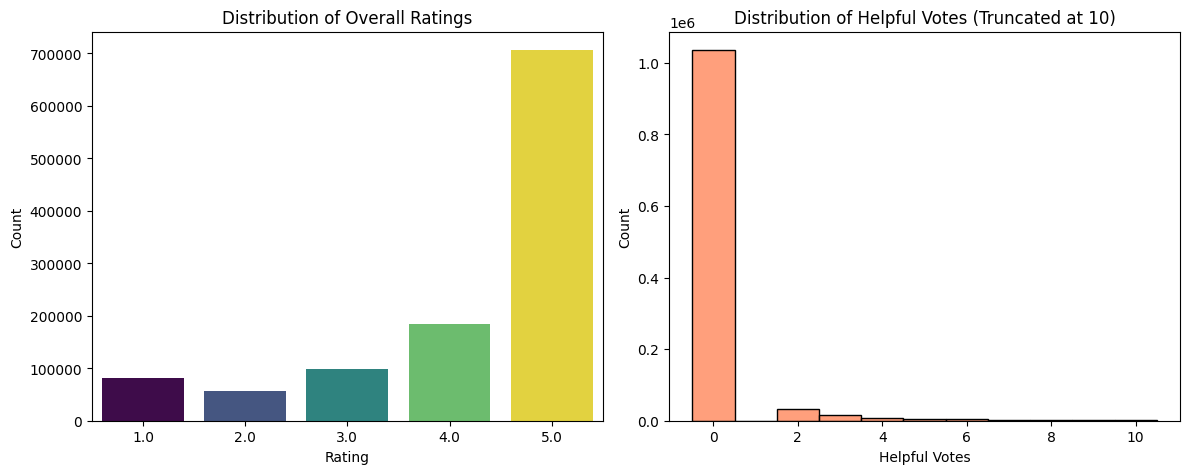

In [6]:
# Sec 4 EDA: sanity checks + rating/helpful-vote distribution plot.
from src.data.eda import print_sanity_checks, plot_rating_helpful_vote_distribution

print_sanity_checks(df)
plot_rating_helpful_vote_distribution(df)   # saves figures/eda/rating_and_helpful_vote_distribution.png (dpi=300)

# 5. Rating-Based Daily Sentiment Time Series

This time series uses star ratings transformed to `[-1, 1]` as the sentiment proxy. Each row is one review day.


In [7]:
# Sec 5 Rating-based daily sentiment time series (proxy for model-based TS).
from src.data.timeseries import build_or_load as build_daily_rating

daily_rating_sentiment_ts = build_daily_rating(df)
print("Daily rating sentiment time series shape:", daily_rating_sentiment_ts.shape)
print(daily_rating_sentiment_ts.describe())
daily_rating_sentiment_ts.head()

Daily rating sentiment time series shape: (4536, 4)
                          review_day  rating_sentiment_naive  \
count                           4536             4536.000000   
mean   2012-06-16 08:26:20.952380928                0.509429   
min              2002-10-23 00:00:00               -1.000000   
25%              2009-06-03 18:00:00                0.483871   
50%              2012-07-17 12:00:00                0.583638   
75%              2015-08-25 06:00:00                0.637154   
max              2018-10-02 00:00:00                1.000000   
std                              NaN                0.303634   

       rating_sentiment_weighted  num_reviews  
count                4536.000000  4536.000000  
mean                    0.428112   248.604938  
min                    -1.000000     1.000000  
25%                     0.303145     6.000000  
50%                     0.500000    57.000000  
75%                     0.639236   353.000000  
max                     1.000000  1

,review_day,rating_sentiment_naive,rating_sentiment_weighted,num_reviews
0,2002-10-23,0.5,0.5,1
1,2002-12-23,1.0,1.0,1
2,2003-06-16,0.5,0.5,1
3,2003-06-25,1.0,1.0,1
4,2003-07-03,-1.0,-1.0,1


# 6. Product-Level Weekly Panel for CPD

Build a weekly product-level panel for popular products. This is the primary input for change-point detection.


Total rows after filtering sparse products: 72739
Number of target products: 92
Weekly product panel shape: (15591, 5)

Panel head:
         asin review_date  rating_sentiment_weighted  rating_sentiment_naive  \
0  B0013G8PTS  2008-11-16                        1.0                     1.0   
1  B0013G8PTS  2010-02-07                        1.0                     1.0   
2  B0013G8PTS  2010-03-07                        1.0                     1.0   
3  B0013G8PTS  2010-03-21                        1.0                     1.0   
4  B0013G8PTS  2010-03-28                        1.0                     1.0   

   num_reviews  
0            2  
1            2  
2            2  
3            2  
4            2  


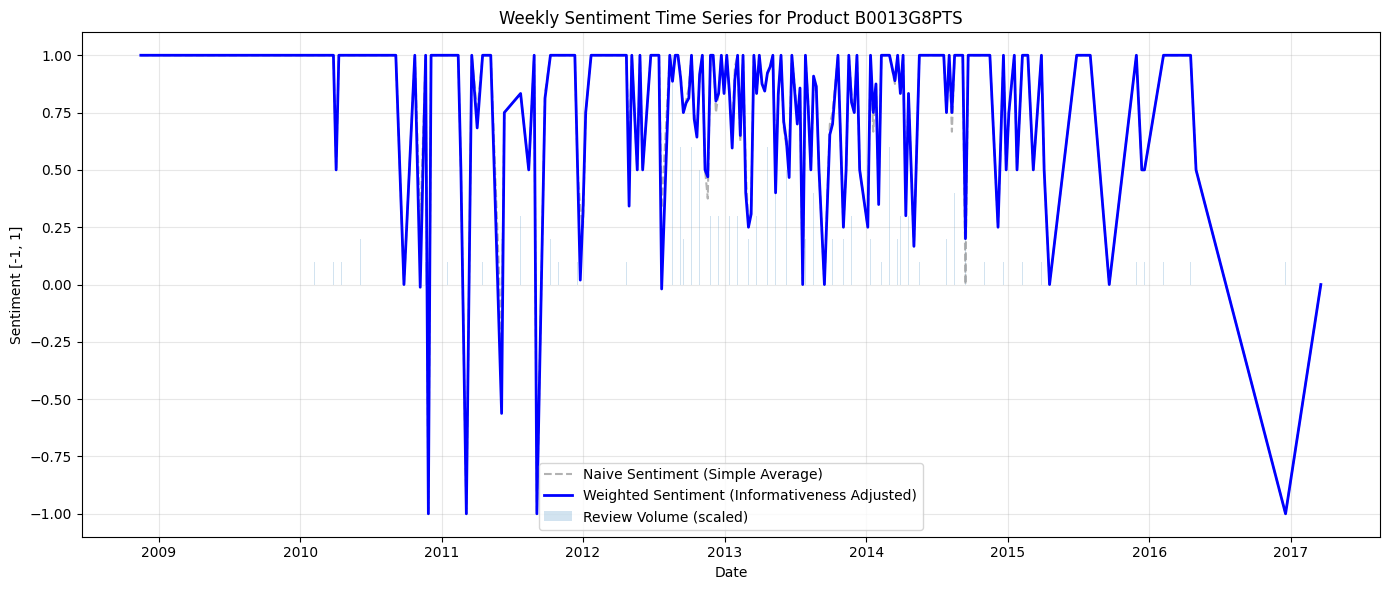

In [8]:
# Sec 6 Product-level weekly panel for popular products (>= 500 reviews).
from src.data.panels import build_or_load_rating_weekly, plot_weekly_sentiment_one_product

rating_weekly_panel, popular_products, df_popular = build_or_load_rating_weekly(df)
print("Total rows after filtering sparse products:", df_popular.shape[0])
print("Number of target products:", len(popular_products))
print("Weekly product panel shape:", rating_weekly_panel.shape)
print("\nPanel head:")
print(rating_weekly_panel.head())

# Visualize one product's trajectory (teaching example)
plot_weekly_sentiment_one_product(rating_weekly_panel, popular_products[0])

# 7. Balanced NLP Dataset

Balanced helpfulness dataset for NLP modeling. This is separate from the time-series pipeline.


In [9]:
# Sec 7 Balanced helpfulness dataset (50/50 vote==0 vs vote>0).
from src.data.nlp_balanced import build_or_load as build_balanced_nlp

df_nlp_train = build_balanced_nlp(df, random_state=RANDOM_STATE)
print(f"Balanced Dataset shape for NLP Training: {df_nlp_train.shape}")
print(f"Class distribution: {df_nlp_train['is_helpful'].value_counts().to_dict()}")
df_nlp_train.head()

Balanced Dataset shape for NLP Training: (184002, 17)
Class distribution: {0: 92001, 1: 92001}


,overall,reviewText,summary,unixReviewTime,vote,verified,asin,informativeness,informativeness_log,vote_capped,review_weight,has_image,review_date,review_day,sentiment,text,is_helpful
0,4.0,Works great. Wish it had more of a groove but...,Works well,1470614400,0,True,B00OS9E6AO,0,0.000000,0,1.500000,0,2016-08-08,2016-08-08,0.5,Works well. Works great. Wish it had more of ...,0
1,5.0,"I love it. It is sturdy, good looking, and pro...",Five Stars,1447545600,0,True,B009E5O9UE,0,0.000000,0,1.500000,0,2015-11-15,2015-11-15,1.0,"Five Stars. I love it. It is sturdy, good look...",0
2,5.0,Great product!,Five Stars,1439337600,26,True,B012CM5EXQ,26,3.295837,13,4.139057,0,2015-08-12,2015-08-12,1.0,Five Stars. Great product!,1
3,5.0,Nothing about the product is worth docking an ...,A god send for mountain bikers.,1457481600,2,True,B00JXXFCY4,2,1.098612,2,2.598612,0,2016-03-09,2016-03-09,1.0,A god send for mountain bikers.. Nothing about...,1
4,3.0,"It is sparkly! It is a nice looking case, but...",sparkles!!,1370822400,0,True,B007PY90EG,0,0.000000,0,1.500000,0,2013-06-10,2013-06-10,0.0,sparkles!!. It is sparkly! It is a nice looki...,0


# 8. Task 1: Sentiment Analysis for Numeric Score
## 8.1 Baseline Sentiment Models

Supervised sentiment regression on the `[-1, 1]` scale. It assigns a score to each review.

**Baseline**: TF-IDF + Ridge picks up basic lexical signal, no context. **VADER** runs alongside as an optional rule-based comparator.


In [10]:
# Sec 8.1 VADER (rule-based) + TF-IDF+Ridge baselines on the shared 70/10/20 split.
# Cache-aware: if per-review score CSVs already exist, load them instead of rescoring 1.13M rows.
import json
from src.task1 import splits as t1_splits
from src.task1 import vader as t1_vader
from src.task1 import tfidf_ridge as t1_ridge
from src.utils.format import (
    make_model_result_row, print_model_comparison_table,
    make_time_series_output_row, print_time_series_output_table,
    make_daily_score_summary_row, print_daily_score_summary_table,
)

# Shared 70/10/20 split (cached; reused by DeBERTa in Sec 8.2)
df_model = t1_splits.filter_to_modeling_subset(df)
print("Modeling rows:", df_model.shape[0])
shared_split = t1_splits.build_or_load_split(df_model)
train_df_model, val_df_model, test_df_model = t1_splits.apply_split(df_model, shared_split)
print(f"  Train: {len(train_df_model)}  Val: {len(val_df_model)}  Test: {len(test_df_model)}")

baseline_run_label = f"full {len(df_model):,} rows"
baseline_split_label = 'shared 70/10/20'
sample_text = "Great phone, worth the price!"

# -- Fast path: if per-review score CSVs + baseline_results.csv all exist,
#    load score columns into df + load metrics table. No retraining/rescoring.
baseline_cache_files = [T1_PER_REVIEW_RIDGE_PATH, T1_BASELINE_RESULTS_PATH,
                        T1_BASELINE_TS_OUTPUTS_PATH, T1_BASELINE_DAILY_SUMMARY_PATH,
                        T1_DAILY_RIDGE_PATH]
if HAS_VADER:
    baseline_cache_files.append(T1_PER_REVIEW_VADER_PATH)

baseline_cache_complete = all(p.exists() for p in baseline_cache_files)

if baseline_cache_complete:
    # Load all score columns from CSVs (each has same row count = len(df) = 1.13M)
    if HAS_VADER:
        df['score_vader'] = pd.read_csv(T1_PER_REVIEW_VADER_PATH,
                                         usecols=['score_vader'])['score_vader'].to_numpy()
    df['score_tfidf_ridge'] = pd.read_csv(T1_PER_REVIEW_RIDGE_PATH,
                                           usecols=['score_tfidf_ridge'])['score_tfidf_ridge'].to_numpy()
    baseline_results = pd.read_csv(T1_BASELINE_RESULTS_PATH)
    baseline_time_series_outputs = pd.read_csv(T1_BASELINE_TS_OUTPUTS_PATH)
    baseline_daily_score_summary = pd.read_csv(T1_BASELINE_DAILY_SUMMARY_PATH)
    daily_baseline_model_score_ts = pd.read_csv(T1_DAILY_BASELINE_COMBINED_PATH) \
        if T1_DAILY_BASELINE_COMBINED_PATH.exists() else pd.read_csv(T1_DAILY_RIDGE_PATH)
    if 'review_day' in daily_baseline_model_score_ts.columns:
        daily_baseline_model_score_ts['review_day'] = pd.to_datetime(daily_baseline_model_score_ts['review_day'])

    # Load (or retrain-if-needed) the Ridge pipeline so downstream code has access
    ridge_pipeline, from_cache = t1_ridge.train_or_load(train_df_model['text'], train_df_model['sentiment'])
    print(f"Ridge pipeline: {'loaded from cache' if from_cache else 'trained fresh'}")

    print(f"\nLoaded baseline scores from cache (no rescoring of 1.13M rows needed)")
    print_model_comparison_table(baseline_results.to_dict('records'), title='Baseline Model Comparison (cached)')

    if HAS_VADER:
        # Teaching snippet (lightweight: just score the single sample, not full df)
        vader_scorer = t1_vader.make_score_function()
        print(f"\nVADER score for sample '{sample_text}': {vader_scorer(sample_text):.4f}")
    print(f"Ridge score for sample '{sample_text}': "
          f"{float(t1_ridge.score_clipped(ridge_pipeline, [sample_text])[0]):.4f}")
else:
    # -- Slow path: cache miss, recompute everything. Takes ~10 min for VADER + ~2 min for Ridge.
    baseline_rows = []
    if HAS_VADER:
        vader_result = t1_vader.evaluate_on_test(test_df_model)
        baseline_rows.append(make_model_result_row(
            model='VADER', mae=vader_result['mae'], rmse=vader_result['rmse'],
            run_label=baseline_run_label, modeling_rows=len(df_model),
            train_rows='0 (rule-based)', validation_rows='-',
            test_rows=len(test_df_model), split_label=baseline_split_label,
        ))
        vader_scorer = t1_vader.make_score_function()
        df['score_vader'] = df['text'].apply(vader_scorer)
        atomic_to_csv(df[['asin', 'unixReviewTime', 'review_date', 'review_day',
                           'overall', 'sentiment', 'informativeness_log', 'score_vader']],
                       T1_PER_REVIEW_VADER_PATH, index=False)
        print(f"\nVADER score for sample '{sample_text}': {vader_scorer(sample_text):.4f}")

    ridge_pipeline, from_cache = t1_ridge.train_or_load(train_df_model['text'], train_df_model['sentiment'])
    print(f"Ridge: {'loaded from cache' if from_cache else 'trained fresh'}")
    ridge_result = t1_ridge.evaluate_on_test(ridge_pipeline, test_df_model)
    baseline_rows.append(make_model_result_row(
        model='TF-IDF + Ridge', mae=ridge_result['mae'], rmse=ridge_result['rmse'],
        run_label=baseline_run_label, modeling_rows=len(df_model),
        train_rows=len(train_df_model), validation_rows=len(val_df_model),
        test_rows=len(test_df_model), split_label=baseline_split_label,
    ))
    df['score_tfidf_ridge'] = t1_ridge.score_clipped(ridge_pipeline, df['text'])
    print(f"Ridge score for sample '{sample_text}': "
          f"{float(t1_ridge.score_clipped(ridge_pipeline, [sample_text])[0]):.4f}")

    baseline_results = print_model_comparison_table(baseline_rows, title='Baseline Model Comparison')
    atomic_to_csv(baseline_results, T1_BASELINE_RESULTS_PATH, index=False)

    def _agg_daily(group):
        out = {'num_reviews': len(group)}
        out['score_tfidf_ridge_naive'] = group['score_tfidf_ridge'].mean()
        out['score_tfidf_ridge_weighted'] = weighted_mean_with_fallback(group, 'score_tfidf_ridge')
        return pd.Series(out)
    daily_baseline_model_score_ts = (
        df.groupby('review_day')[['score_tfidf_ridge', 'informativeness_log']]
        .apply(_agg_daily).reset_index()
    )
    ts_row = make_time_series_output_row(
        model='TF-IDF + Ridge', run_label=baseline_run_label,
        score_column='score_tfidf_ridge',
        daily_naive_column='score_tfidf_ridge_naive',
        daily_weighted_column='score_tfidf_ridge_weighted',
        daily_rows=daily_baseline_model_score_ts.shape[0],
        review_score_file=T1_PER_REVIEW_RIDGE_PATH,
        daily_score_file=T1_DAILY_RIDGE_PATH,
    )
    baseline_time_series_outputs = print_time_series_output_table([ts_row], title='Time Series Outputs (Ridge)')
    baseline_daily_score_summary = print_daily_score_summary_table(
        [make_daily_score_summary_row(
            model='TF-IDF + Ridge', run_label=baseline_run_label,
            daily_frame=daily_baseline_model_score_ts,
            naive_col='score_tfidf_ridge_naive', weighted_col='score_tfidf_ridge_weighted')],
        title='Daily Score Summary (Ridge)')

    atomic_to_csv(df[['asin', 'unixReviewTime', 'review_date', 'review_day',
                      'overall', 'sentiment', 'informativeness_log', 'score_tfidf_ridge']],
                  T1_PER_REVIEW_RIDGE_PATH, index=False)
    atomic_to_csv(daily_baseline_model_score_ts[['review_day',
                                                  'score_tfidf_ridge_naive',
                                                  'score_tfidf_ridge_weighted',
                                                  'num_reviews']],
                  T1_DAILY_RIDGE_PATH, index=False)
    combined_cols = ['asin', 'unixReviewTime', 'review_date', 'review_day',
                     'overall', 'sentiment', 'informativeness_log', 'score_tfidf_ridge']
    if 'score_vader' in df.columns:
        combined_cols.append('score_vader')
    atomic_to_csv(df[combined_cols], T1_PER_REVIEW_BASELINE_COMBINED_PATH, index=False)
    atomic_to_csv(daily_baseline_model_score_ts, T1_DAILY_BASELINE_COMBINED_PATH, index=False)
    atomic_to_csv(baseline_time_series_outputs, T1_BASELINE_TS_OUTPUTS_PATH, index=False)
    atomic_to_csv(baseline_daily_score_summary, T1_BASELINE_DAILY_SUMMARY_PATH, index=False)
    atomic_write_text(T1_BASELINE_META_PATH, json.dumps({'status': 'complete',
                                                          'has_vader': HAS_VADER,
                                                          'models': [r['Model'] for r in baseline_rows]},
                                                          indent=2))
    print(f"\nDaily baseline score rows: {daily_baseline_model_score_ts.shape[0]}")

Modeling rows: 1127665
  Train: 789365  Val: 112767  Test: 225533
Ridge pipeline: loaded from cache

Loaded baseline scores from cache (no rescoring of 1.13M rows needed)

=== Baseline Model Comparison (cached) ===
+----------------+---------------------+---------------+----------------+-----------------+-----------+-----------------+--------+--------+
| Model          | Run                 | Modeling Rows | Train Rows     | Validation Rows | Test Rows | Split           | MAE    | RMSE   |
+----------------+---------------------+---------------+----------------+-----------------+-----------+-----------------+--------+--------+
| VADER          | full 1,127,665 rows | 1,127,665     | 0 (rule-based) | -               | 225,533   | shared 70/10/20 | 0.3765 | 0.5255 |
| TF-IDF + Ridge | full 1,127,665 rows | 1,127,665     | 789,365        | 112,767         | 225,533   | shared 70/10/20 | 0.2146 | 0.3300 |
+----------------+---------------------+---------------+----------------+------------

## 8.2 DeBERTa-v3-base LoRA Fine-Tuning With Resume Support

DeBERTa-v3-base fine-tuned with LoRA/PEFT, same `[-1, 1]` target.

Base weights stay frozen, LoRA adapters + regression head do the learning. Val-RMSE picks the best checkpoint and triggers early stopping. Checkpoints + scoring progress live in `models/task1_deberta_lora/` and `cache/`, so reruns just resume.


### DeBERTa's Disentangled Attention

Disentangled attention between content and position:
$$
A_{i,j} = Q_i^c {K_j^c}^T + Q_i^c {K_{i,j}^r}^T + Q_{i,j}^r {K_j^c}^T + Q_{i,j}^r {K_{i,j}^r}^T
$$
Separating content from position lets the model see how word order and meaning interact. Sentiment is sensitive to subtle phrasing, so this helps.


In [11]:
# Sec 8.2 DeBERTa-v3-base + LoRA fine-tuning (resume-aware, cache-aware).
# All the heavy lifting is in src/task1/deberta*.py - this cell orchestrates the 9-step pipeline:
#   prepare_modeling_subset -> apply_shared_split -> train_or_load (with resume)
#   -> compute_test_metrics (cache-aware) -> score_full_dataset (chunked, checkpointed)
#   -> aggregate_daily -> save_full_outputs
from src.task1 import deberta
from src.task1.deberta_internals import LORA_R, LORA_ALPHA
from src.utils.format import (make_model_result_row, print_model_comparison_table,
                               make_time_series_output_row, print_time_series_output_table,
                               make_daily_score_summary_row, print_daily_score_summary_table)

if not HAS_TRANSFORMERS:
    print("transformers/peft/datasets not installed - DeBERTa skipped.")
else:
    df_deberta = deberta.prepare_modeling_subset(df)
    train_deberta, val_deberta, test_deberta = deberta.apply_shared_split(df_deberta)
    print(f"LoRA r={LORA_R}, alpha={LORA_ALPHA}  (1.73% trainable of 188M total)")
    print(f"DeBERTa LoRA train: {len(train_deberta)}  val: {len(val_deberta)}  test: {len(test_deberta)}")

    # Train or load (resume-aware via _SUCCESS marker + RESUME_COMPATIBLE_CONFIG_KEYS)
    state = deberta.train_or_load(train_deberta, val_deberta, test_deberta)
    test_metrics = deberta.compute_test_metrics(state, test_deberta)
    print(f"\nDeBERTa LoRA test:  MAE={test_metrics['mae']:.4f}  RMSE={test_metrics['rmse']:.4f}"
          f"  (from_cache={test_metrics['from_cache']})")

    # Score full df (chunked with per-chunk atomic checkpointing of deberta_progress.csv)
    df = deberta.score_full_dataset(df, state, force_rescore=False)
    # Teaching snippet: same review through all three models
    if 'score_vader' in df.columns and 'score_tfidf_ridge' in df.columns:
        sample_idx = df.index[df['text'].str.len().between(30, 100)][0]
        print(f"\nSample review (row {sample_idx}, true sentiment={df.loc[sample_idx, 'sentiment']:+.2f}):")
        print(f"  text: {df.loc[sample_idx, 'text'][:80]}...")
        for col, name in [('score_vader', 'VADER'), ('score_tfidf_ridge', 'Ridge'),
                          ('score_deberta_v3_base_lora', 'DeBERTa+LoRA')]:
            if col in df.columns:
                print(f"  {name:14s}: {float(df.loc[sample_idx, col]):+.4f}")

    # Daily aggregation + save
    daily_deberta_score_ts = deberta.aggregate_daily(df)
    deberta.save_full_outputs(df, daily_deberta_score_ts, test_metrics, state)

    # 4-way model comparison table (combine baseline + DeBERTa)
    deberta_row = make_model_result_row(
        model='DeBERTa-v3-base + LoRA',
        mae=test_metrics['mae'], rmse=test_metrics['rmse'],
        run_label=f"full {len(df_deberta):,} rows",
        modeling_rows=len(df_deberta),
        train_rows=len(train_deberta), validation_rows=len(val_deberta),
        test_rows=len(test_deberta), split_label='shared 70/10/20',
    )
    if 'baseline_results' in globals() and isinstance(baseline_results, pd.DataFrame):
        model_comparison_results = pd.concat([baseline_results, pd.DataFrame([deberta_row])],
                                              ignore_index=True)
    else:
        model_comparison_results = pd.DataFrame([deberta_row])
    model_comparison_results = print_model_comparison_table(
        model_comparison_results, title='Model Comparison (DeBERTa complete)')
    atomic_to_csv(model_comparison_results, T1_MODEL_COMPARISON_PATH, index=False)

# Free DeBERTa state before Task 2 routes
cleanup_gpu(globals(), 'state')

LoRA r=16, alpha=32  (1.73% trainable of 188M total)
DeBERTa LoRA train: 789365  val: 112767  test: 225533
Final LoRA adapter config differs only in memory-only settings: ['batch_size', 'eval_batch_size']
Reusing existing weights (these fields don't change the trained model).
LoRA checkpoint directory: /Users/angkai/Desktop/1090/1090b-ms4/models/task1_deberta_lora/checkpoints
LoRA final adapter directory: /Users/angkai/Desktop/1090/1090b-ms4/models/task1_deberta_lora/final_model
Last complete LoRA checkpoint: /Users/angkai/Desktop/1090/1090b-ms4/models/task1_deberta_lora/checkpoints/checkpoint-37002
Complete final LoRA adapter exists: True


Setting TOKENIZERS_PARALLELISM=false for forked processes.


Map (num_proc=1):   0%|          | 0/789365 [00:00<?, ? examples/s]

Setting TOKENIZERS_PARALLELISM=false for forked processes.


Map (num_proc=1):   0%|          | 0/112767 [00:00<?, ? examples/s]

Setting TOKENIZERS_PARALLELISM=false for forked processes.


Map (num_proc=1):   0%|          | 0/225533 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier

Using saved final DeBERTa LoRA adapter, skipping training.
trainable params: 0 || all params: 187,668,482 || trainable%: 0.0000
Dropping unsupported TrainingArguments: ['overwrite_output_dir']
Early stopping enabled: metric=eval_rmse, patience=3, threshold=0.0
Loaded cached DeBERTa test metrics from /Users/angkai/Desktop/1090/1090b-ms4/outputs/task1/evaluation/deberta_test_metrics.json

DeBERTa LoRA test:  MAE=0.1053  RMSE=0.2118  (from_cache=True)
Loaded existing full DeBERTa LoRA scores from /Users/angkai/Desktop/1090/1090b-ms4/outputs/task1/per_review/deberta_lora.csv
DeBERTa full scoring load elapsed: 0.2s

Sample review (row 59, true sentiment=-0.50):
  text: CASE. DON'T CARE FOR IT.  GAVE IT AS A GIFT AND THEY WERE OKAY WITH IT.  JUST NO...
  VADER         : +0.2896
  Ridge         : -0.1107
  DeBERTa+LoRA  : -0.2340
Saved DeBERTa LoRA review-level score file to /Users/angkai/Desktop/1090/1090b-ms4/outputs/task1/per_review/deberta_lora.csv
Saved DeBERTa LoRA daily score file to /

## 8.3 Model Time Series Comparison & Visualization

Overlapping daily rows: 4,536
Date range: 2002-10-23 to 2018-10-02
Daily review-count summary: mean=248.60 median=57


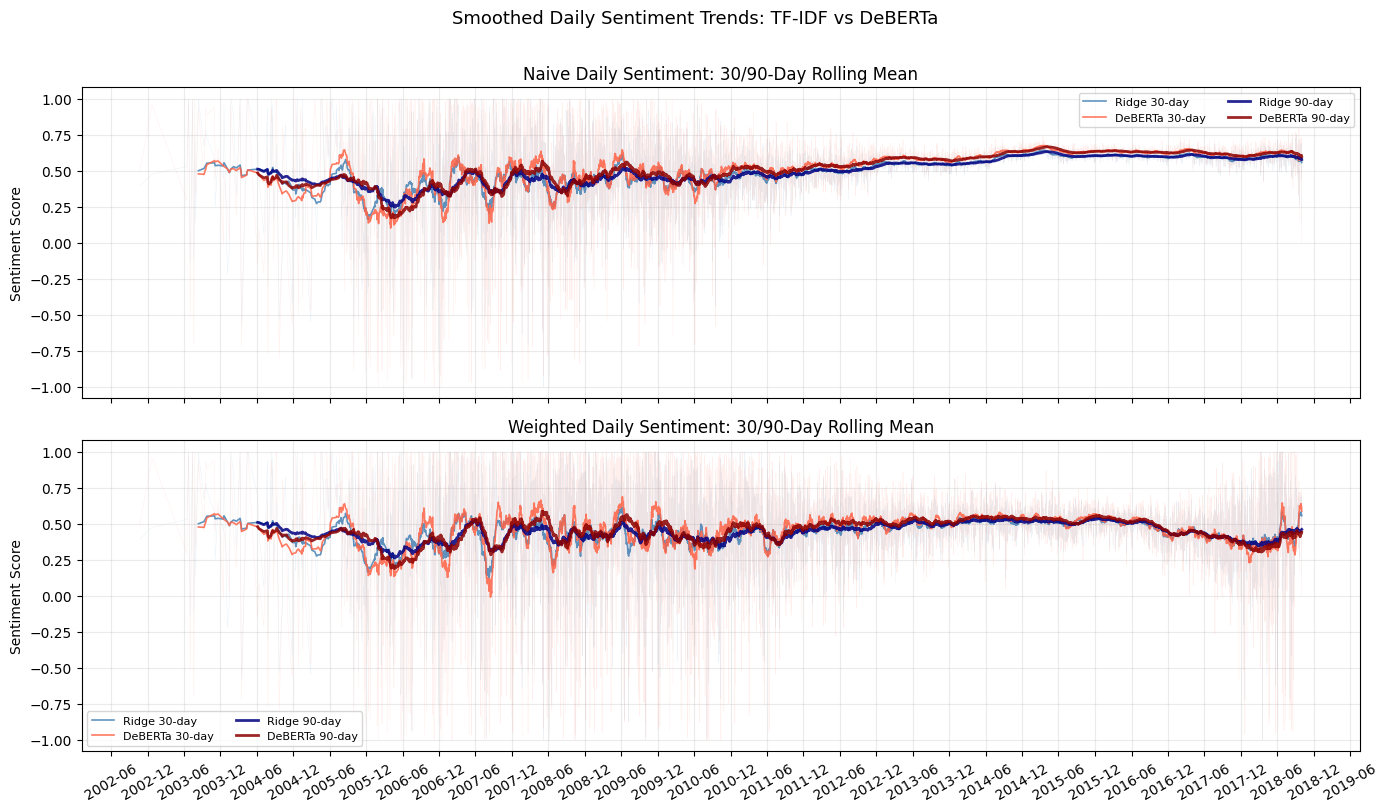

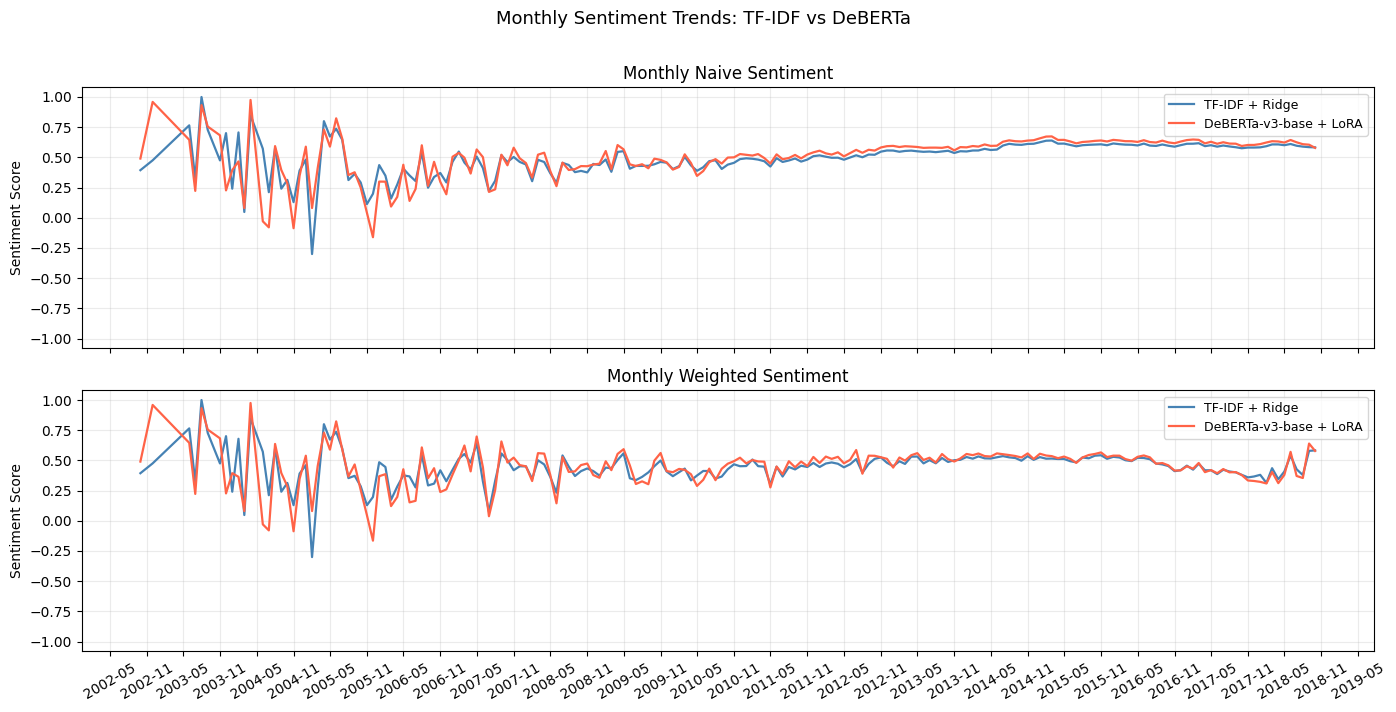

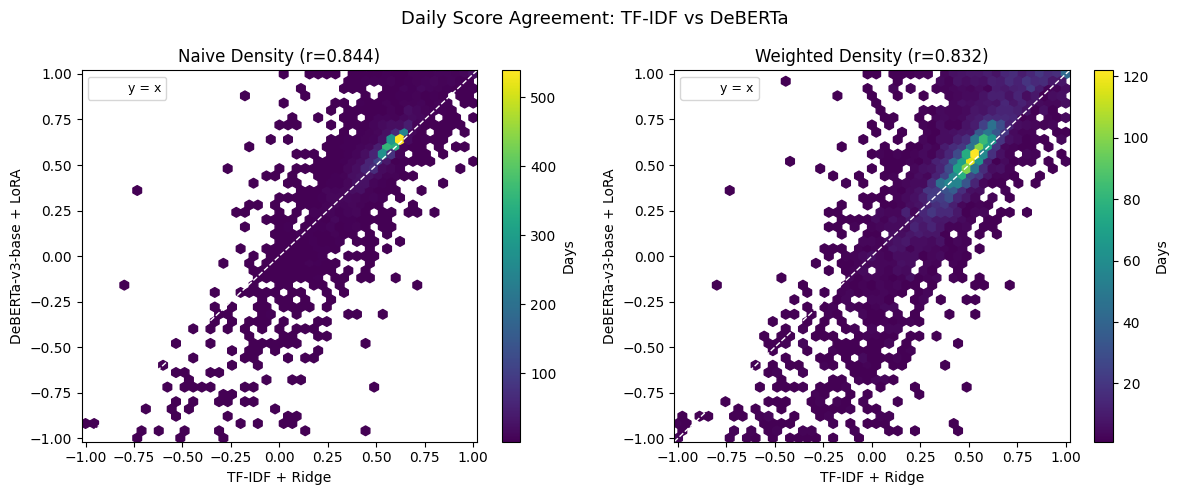

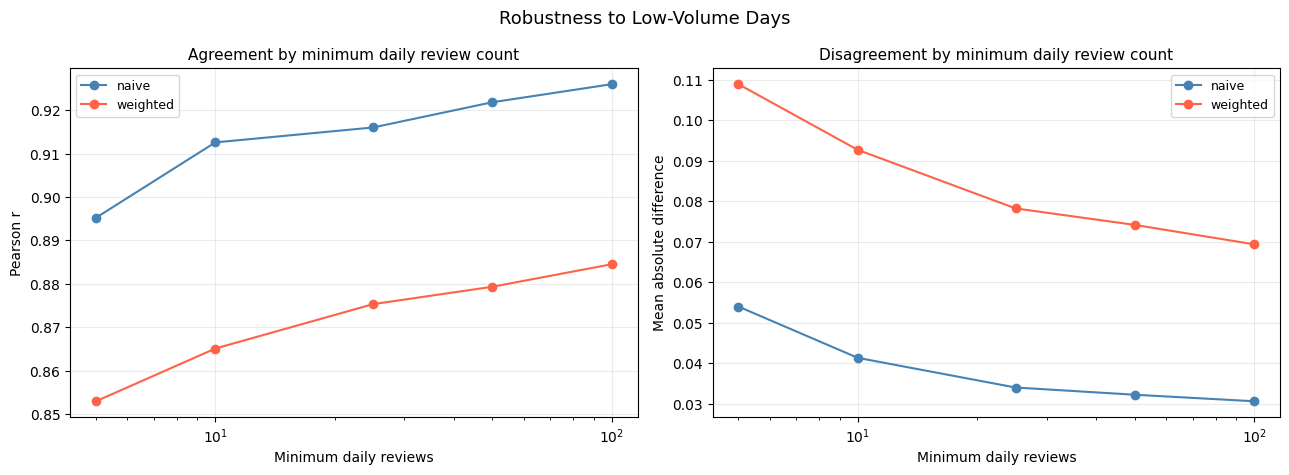

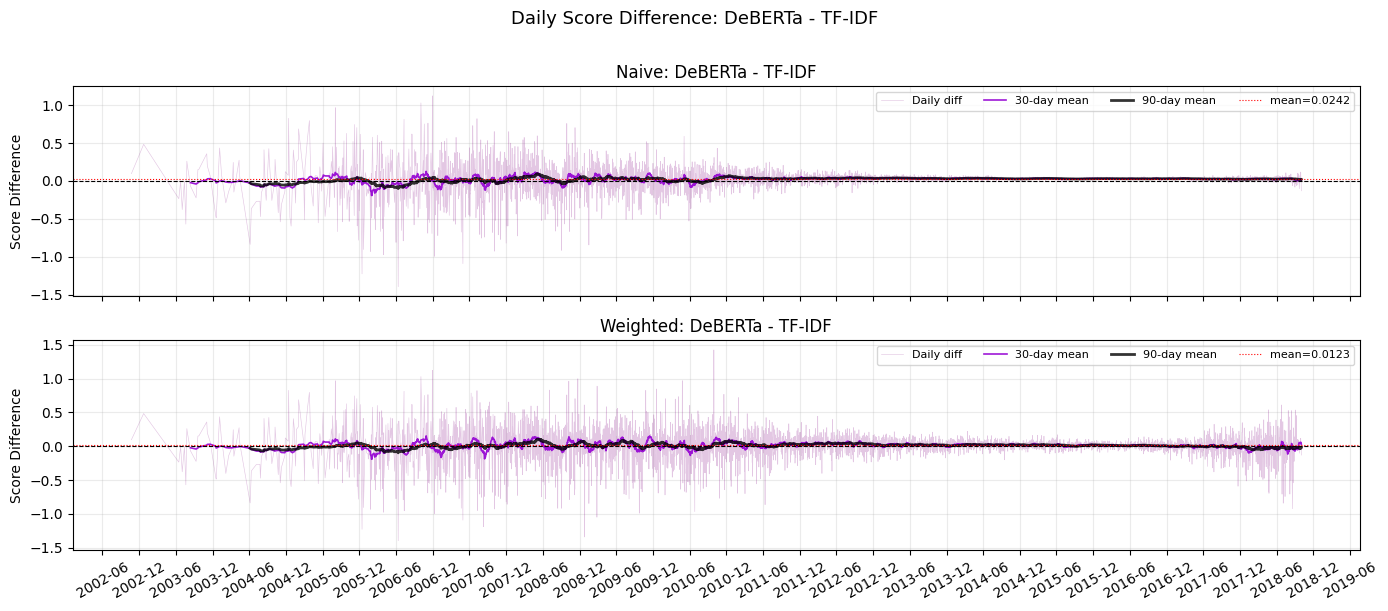

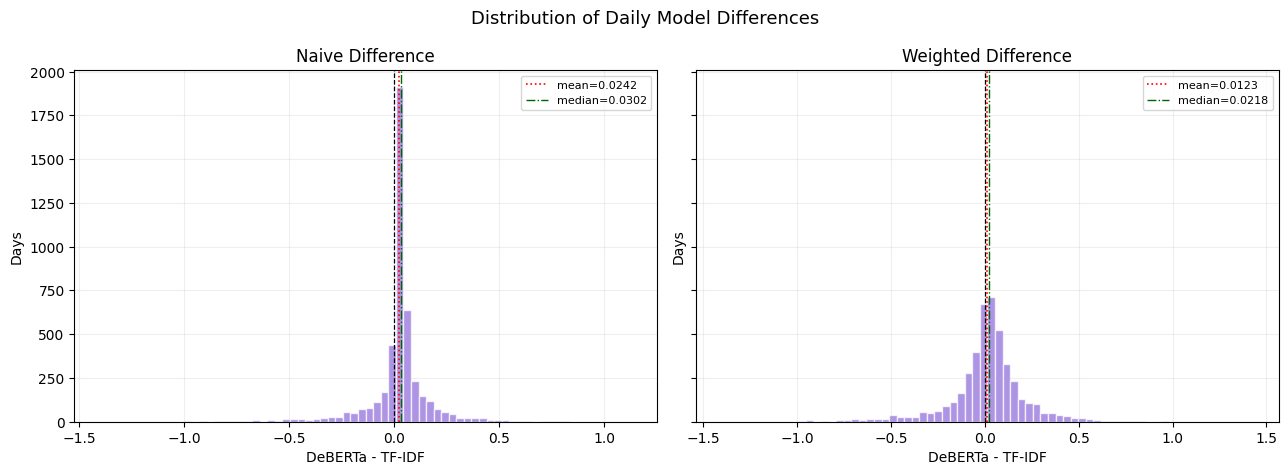

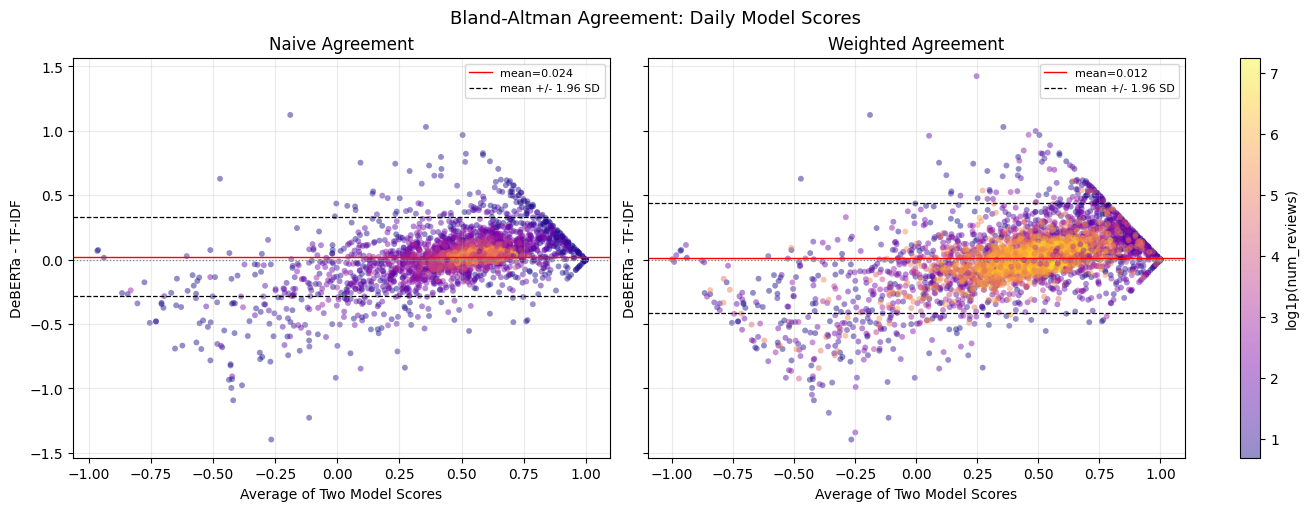

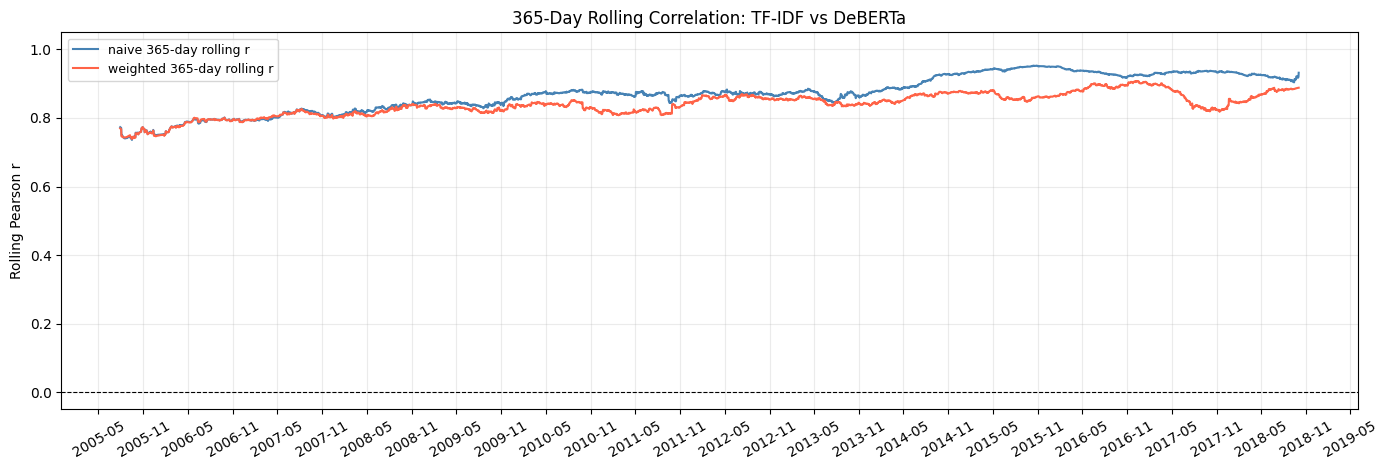


=== Key Findings for Report ===
+----------------------------+----------+------------------------------+--------+
| Finding                    | Variant  | Metric                       | Value  |
+----------------------------+----------+------------------------------+--------+
| Daily model agreement      | naive    | Pearson r                    | 0.8442 |
| Rank-order agreement       | naive    | Spearman r                   | 0.8147 |
| Average level bias         | naive    | Mean DeBERTa - Ridge         | 0.0242 |
| Typical daily disagreement | naive    | Mean absolute difference     | 0.0901 |
| High-volume robustness     | naive    | Pearson r, num_reviews >= 25 | 0.9160 |
| Largest local disagreement | naive    | Max absolute difference      | 1.3964 |
| Daily model agreement      | weighted | Pearson r                    | 0.8322 |
| Rank-order agreement       | weighted | Spearman r                   | 0.8083 |
| Average level bias         | weighted | Mean DeBERTa - Ridge   

In [12]:
# Sec 8.3 Daily TS comparison: Ridge vs DeBERTa with summary tables + 4 main + 4 diagnostic plots.
from src.task1 import compare

daily_baseline, daily_deberta = compare.load_daily_series()
ts_compare = compare.build_comparison_frame(daily_baseline, daily_deberta)
print(f"Overlapping daily rows: {len(ts_compare):,}")
print(f"Date range: {ts_compare['review_day'].min().date()} to {ts_compare['review_day'].max().date()}")
print(f"Daily review-count summary: mean={ts_compare['num_reviews'].mean():.2f} "
      f"median={ts_compare['num_reviews'].median():.0f}")

# Build summary tables (correlations, top disagreement, monthly, key findings)
tables = compare.build_summary_tables(ts_compare)
compare.add_rolling_features(ts_compare)

# Generate 4 main + 4 diagnostic plots (all dpi=300)
plot_records = []
compare.plot_main_figures(ts_compare, tables['monthly_compare'], tables['volume_summary'], plot_records)
compare.plot_diagnostic_figures(ts_compare, plot_records)

# Save all CSVs + plot manifest
compare.save_all_outputs(ts_compare, tables, plot_records)
compare.display_summary_tables(tables)

## 8.4 Task 1 Final Output Summary

List the key output files written under `outputs/`, `models/`, and `cache/`.


In [13]:
# Sec 8.4 Final output manifest - verify every artifact this notebook produces exists.
from src.task1 import summary

ok_count, missing_count = summary.verify_all()
summary.check_data_dir_hygiene()

=== Expected outputs ===
  exists    /Users/angkai/Desktop/1090/1090b-ms4/cache/cleaned/df.pkl
  exists    /Users/angkai/Desktop/1090/1090b-ms4/cache/cleaned/meta.json
  exists    /Users/angkai/Desktop/1090/1090b-ms4/cache/splits/split.csv
  exists    /Users/angkai/Desktop/1090/1090b-ms4/cache/splits/meta.json
  exists    /Users/angkai/Desktop/1090/1090b-ms4/cache/panels/rating_weekly_panel.csv
  exists    /Users/angkai/Desktop/1090/1090b-ms4/cache/panels/rating_weekly_panel.meta.json
  exists    /Users/angkai/Desktop/1090/1090b-ms4/cache/nlp_balanced/train.csv
  exists    /Users/angkai/Desktop/1090/1090b-ms4/cache/nlp_balanced/meta.json
  exists    /Users/angkai/Desktop/1090/1090b-ms4/models/task1_tfidf_ridge/pipeline.pkl
  exists    /Users/angkai/Desktop/1090/1090b-ms4/models/task1_deberta_lora/checkpoints
  exists    /Users/angkai/Desktop/1090/1090b-ms4/models/task1_deberta_lora/final_model
  exists    /Users/angkai/Desktop/1090/1090b-ms4/models/task1_deberta_lora/final_model/_SUCCE

True

## 8.5 Task 1 Final Model Comparison

Held-out test split (n = 225,533 reviews, RMSE-driven best epoch). All metrics from `outputs/task1/evaluation/model_comparison.csv`.

| Model | MAE | RMSE |
|---|---|---|
| **DeBERTa-v3-base + LoRA** | **0.1053** | **0.2118** |
| TF-IDF + Ridge | 0.2146 | 0.3300 |
| VADER (rule-based) | 0.3765 | 0.5255 |

**Ranking** (lower = better): `DeBERTa + LoRA` < `TF-IDF + Ridge` < `VADER`

- **DeBERTa + LoRA** achieves the lowest MAE/RMSE by a 2x margin: context-aware embedding + parameter-efficient fine-tuning.
- **TF-IDF + Ridge** sits in the middle: decent lexical signal but no context.
- **VADER** is rule-based with no learning: weakest baseline by construction.

Full per-review predictions exported to `outputs/task1/per_review/{vader, tfidf_ridge, deberta_lora}.csv`. The DeBERTa predictions feed into Task 2 panels (Sec 9.1).

In [14]:
# Sec 9.1 Build DeBERTa-weighted product-month + product-week panels.
from src.task2.records import build_or_load_panels

monthly_panel, weekly_panel = build_or_load_panels(df)
print(f"\nMonthly panel: {monthly_panel.shape}  Weekly panel: {weekly_panel.shape}")

Loaded Task 2 panels from cache.
  Monthly: (8065, 11)  Weekly: (19754, 11)

Monthly panel: (8065, 11)  Weekly panel: (19754, 11)


## 9.2 Legacy Task 2 Baseline

This cell preserves the multivariate `ruptures.Pelt(model='rbf')` baseline.
Outputs `outputs/task2_legacy_monthly/change_points.csv` with phase labels (Low/Medium/High) based on a 7-feature panel (Task 1 score + Amazon sentiment + star rating + review count + verified ratio + score variance + helpful votes). A weekly counterpart (`outputs/task2_legacy_weekly/`) is produced by Sec 9.W.10 (weekly legacy section, parallel to this cell).

Kept as an **ablation comparator** to the cleaner univariate Route 1 in Sec 9.4.


In [15]:
# Sec 9.2 Legacy multivariate rbf-PELT baseline (kept as ablation comparator).
from src.task2.legacy import run_legacy_baseline

legacy_panel, legacy_segments_df = run_legacy_baseline(df)
print(f"\nLegacy segmented phases: {len(legacy_segments_df)}")

Loaded Task 2 legacy baseline from cache: (34724, 14)

Legacy segmented phases: 34724


In [16]:
# Sec 9.3 Per-product training records: z-score norm + RARE bucket + 1/sqrtn shrinkage scale.
from src.task2.records import build_or_load_records, weighted_sentiment_score, shrinkage_loss

records, asin_to_id, n_products, weight_decay_scale = build_or_load_records(monthly_panel)
print(f"\nTotal panel rows: {sum(len(r['series_norm']) for r in records):,}")
print(f"Total products: {len(records)}  (incl. RARE bucket ID=0)")

Loaded 274 product records from cache (0.0s)
Total panel rows: 8,065

Total panel rows: 8,065
Total products: 274  (incl. RARE bucket ID=0)


In [17]:
# Sec 9.4 Route 1: PELT (CROPS-elbow L2) + ClaSP. Synthetic AR(1) calibration + per-product runs.
from src.task2 import pelt as r1_pelt

classical_df, pelt_lookup, calibration = r1_pelt.run_route1(records, n_jobs=8)
print(f"\nPELT cps loaded for {len(pelt_lookup)} products")
print(f"Avg boundaries/product: {np.mean([len(v) for v in pelt_lookup.values()]):.2f}")

Loaded Route 1 from cache: 273 products
Average PELT(l2) boundaries per product: 1.21

PELT cps loaded for 273 products
Avg boundaries/product: 1.21


In [18]:
# Sec 9.5 Route 2: AutoCPD MLP + product embedding. 50K synth + ~2K PELT weak labels.
from src.task2.autocpd import train_or_load_route2
from src.task2.synth import empirical_sigma_norm

sigma_norm = empirical_sigma_norm(records)
r2_state = train_or_load_route2(records, pelt_lookup, n_products,
                                  weight_decay_scale, sigma_norm)
autocpd_df = r2_state['cps_df']
autocpd_probs = r2_state['probs_dict']
X_train = r2_state['X_train']
y_train = r2_state['y_train']
asin_train = r2_state['asin_train']
print(f"\nRoute 2 cps loaded for {len(autocpd_probs)} products")

cleanup_gpu(globals(), 'r2_state')

Loaded Route 2 from cache: 274 products
  X_train: (52006, 24)  positive rate: 0.484
Route 2 done (from cache).

Route 2 cps loaded for 274 products


In [19]:
# Sec 9.6 Route 3: TST encoder + MVP pretraining + DeepAR-style product bias.
from src.task2.tst import train_or_load_route3

r3_state = train_or_load_route3(records, X_train, y_train, asin_train,
                                 n_products, weight_decay_scale)
tst_df = r3_state['cps_df']
tst_probs = r3_state['probs_dict']
print(f"\nRoute 3 cps loaded for {len(tst_probs)} products")

cleanup_gpu(globals(), 'r3_state')

Loaded Route 3 from cache: 274 products
Route 3 done (from cache).

Route 3 cps loaded for 274 products


In [20]:
# Sec 9.7 Route 4: MOMENT-1-large (385M) + LoRA r=32 + 2-layer MLP side-channel.
from src.task2.moment import train_or_load_route4

r4_state = train_or_load_route4(records, X_train, y_train, asin_train,
                                 n_products, weight_decay_scale)
moment_df = r4_state['cps_df']
moment_probs = r4_state['probs_dict']
print(f"\nRoute 4 cps loaded for {len(moment_probs)} products"
      if moment_probs else "Route 4 skipped (MOMENT/CUDA missing)")

cleanup_gpu(globals(), 'r4_state')

Loaded Route 4 from cache: 274 products

Route 4 cps loaded for 274 products


## 9.8 Hybrid PELT-Style Decoding

The hybrid score is **a decoding score, not a training loss** (the segment set S is discrete and
non-differentiable, so it can't be optimized end-to-end with gradients).

**Two-stage decoding**:
1. PELT(L2 + CROPS-elbow) proposes candidate boundaries from `series_raw` per series.
2. A neural-prior filter keeps each candidate `t` iff `p_neural(t) >= exp(-1/gamma)`. This is a tractable
   pragmatic surrogate for the ideal joint objective `Sum_seg C(seg) + beta|S| - gamma Sum_{t in S} log p_t`
   (which would require modifying PELT's cost function with position-dependent penalties).

**Effect of gamma** (swept in `{0.5, 1.0, 2.0}`, three distinct cps sets produced):
- gamma = 0.5 -> threshold ~ 0.135 -> loose filter, behaves like pure PELT (neural weakly vetoes only very
  low-confidence boundaries)
- gamma = 1.0 -> threshold ~ 0.368 -> moderate filter
- gamma = 2.0 -> threshold ~ 0.607 -> strict filter, keep only PELT boundaries the neural model strongly
  endorses

`gamma` therefore controls how much we trust the neural prior to veto PELT proposals. Within the kept set,
boundaries are ranked by `-gamma log p_t` (most confidently endorsed first).

In [21]:
# Sec 9.8 Hybrid decoding: PELT(L2) candidates + neural-prior filter (gamma in {0.5, 1.0, 2.0}).
from src.task2.hybrid import run_hybrid_decoding

hybrid_df = run_hybrid_decoding(records, autocpd_probs)
print(f"\nHybrid gamma-sweep: {hybrid_df['gamma'].unique().tolist()}")
for gamma in [0.5, 1.0, 2.0]:
    sub = hybrid_df[hybrid_df['gamma'] == gamma]
    print(f"  gamma={gamma}: avg {sub['n_cps'].mean():.2f} cps/product")

Loaded hybrid decoding from cache: (819, 4)

Hybrid gamma-sweep: [0.5, 1.0, 2.0]
  gamma=0.5: avg 0.18 cps/product
  gamma=1.0: avg 0.04 cps/product
  gamma=2.0: avg 0.02 cps/product


In [22]:
# Sec 9.9 Evaluation: Top-K re-extract + F1 vs PELT + phase profiling + KMeans 4 clusters.
from src.task2.evaluate import run_evaluation

eval_df, phase_df = run_evaluation(records, classical_df, pelt_lookup)

Loaded evaluation from cache:  F1=(1710, 8)  phases=(605, 10)

=== F1 vs PELT (mean per route) ===

Monthly F1 by route x tolerance window (sensitivity analysis):
                            mean  median  count
route   tolerance_periods                      
autocpd 2                  0.157     0.0    190
        3                  0.328     0.0    190
        4                  0.448     0.5    190
moment  2                  0.120     0.0    190
        3                  0.244     0.0    190
        4                  0.343     0.0    190
tst     2                  0.161     0.0    190
        3                  0.323     0.0    190
        4                  0.430     0.4    190

Monthly Precision / Recall by route x tolerance (over-detect vs under-detect):
                           precision  recall
route   tolerance_periods                   
autocpd 2                      0.162   0.154
        3                      0.343   0.321
        4                      0.465   0.440
mome

## 9.W Weekly Task 2 Pipeline (Full Parallel Design)

Mirrors monthly Sec 9.3-Sec 9.9 on the weekly DeBERTa panel (~2.5x more raw periods per product, ~6.7x more sliding-window training samples per product, weak-label positive rate ~7.5% - slightly more imbalanced than monthly's ~12.3% because longer weekly series produce more non-boundary windows). Every weekly route uses the **same architecture and engineering framework** as its monthly counterpart (AdamW + CosineAnnealingLR + BestStateTracker + early stopping), only the input panel and the weak-label source (weekly PELT) differ.

The subsection numbering `Sec 9.W.X` indicates direct correspondence with monthly `Sec 9.X`:

| Weekly subsection | Mirrors monthly |
|---|---|
| Sec 9.W.3 + Sec 9.W.4 - Weekly Data Prep + R1 PELT (combined) | Sec 9.3 + Sec 9.4 |
| Sec 9.W.5 - Weekly Route 2 AutoCPD | Sec 9.5 |
| Sec 9.W.6 - Weekly Route 3 TST | Sec 9.6 |
| Sec 9.W.7 - Weekly Route 4 MOMENT | Sec 9.7 |
| Sec 9.W.8 - Weekly Hybrid Decoding | Sec 9.8 |
| Sec 9.W.9 - Weekly Evaluation + Phase Profiling | Sec 9.9 |
| Sec 9.W.10 - Weekly Legacy Baseline | Sec 9.2 (moved to end of weekly section) |
| Sec 9.W.11 - Cross-Granularity Summary | (weekly-only, no monthly counterpart) |

Each weekly cell calls a `t2_weekly.*` function with cache-aware fast paths - re-runs that find existing `outputs/task2_*_weekly/` files load them instead of retraining. To force a re-run, delete the target file or pass `force_rerun=True` to the call.

Outputs go to `outputs/task2_*_weekly/` (the `_weekly` suffix mirrors the `_monthly` suffix on the corresponding monthly directories).

In [23]:
# Sec 9.W.3-Sec 9.W.4 Weekly data prep + R1 PELT.
from src.task2 import weekly as t2_weekly

weekly_state = t2_weekly.prepare_weekly_data()
records_weekly = weekly_state['records_weekly']
pelt_lookup_weekly = weekly_state['pelt_lookup_weekly']
classical_df_weekly = pd.read_csv(t2_weekly.T2_R1_WEEKLY_CP_PATH)
print(f"\nWeekly: {len(records_weekly)} records, "
      f"{len(pelt_lookup_weekly)} PELT lookups, "
      f"{weekly_state['X_train_weekly'].shape[0]} training rows")

Loaded weekly data prep + R1 from cache: 274 records, 63461 training rows  (cache hit)

Weekly: 274 records, 272 PELT lookups, 63461 training rows


## 9.W.5 Weekly Route 2, AutoCPD-style

Mirror of Sec 9.5 (monthly Route 2). Same `AutoCPDClassifier` architecture (window + product embedding concat, 2 hidden layers + BatchNorm + GELU + Dropout, 2-class output) and same training framework.

**Weekly-specific differences from monthly**:
- Input: weekly z-scored sentiment windows from `records_weekly` (week-level, not month-level)
- Weak labels: `pelt_lookup_weekly` from Sec 9.W.3 (weekly PELT boundaries)
- Training set is larger: ~13K weak labels (vs ~2K monthly), giving denser supervision
- Positive label rate ~ 7.5% (vs ~12.3% monthly), slightly more imbalanced because longer weekly series produce more non-boundary windows

In [24]:
# Sec 9.W.5 Weekly Route 2 (AutoCPD).
autocpd_probs_weekly = t2_weekly.train_route2_weekly(weekly_state)
print(f"\nWeekly R2: {len(autocpd_probs_weekly)} products")

Loaded Weekly R2 from cache (274 products). To force rebuild, delete the model/probs/csv files.

Weekly R2: 274 products


## 9.W.6 Weekly Route 3, TST + MVP Pretraining

Mirror of Sec 9.6 (monthly Route 3). Same two-phase BERT-style training (Phase 1 = masked-value pretraining, Phase 2 = boundary fine-tune with DeepAR-style additive product bias), same architecture (`d_model=64`, 3 layers, 8 heads), same optimizer/scheduler.

**Weekly-specific differences from monthly**:
- Phase 1 (MVP) input: weekly z-scored windows (denser stride = more imputation training examples)
- Phase 2 input: same as Weekly Route 2 (~13K weak labels, ~7.5% positive rate)

In [25]:
# Sec 9.W.6 Weekly Route 3 (TST + MVP).
tst_probs_weekly = t2_weekly.train_route3_weekly(weekly_state)
print(f"\nWeekly R3: {len(tst_probs_weekly)} products")

Loaded Weekly R3 from cache (274 products).

Weekly R3: 274 products


## 9.W.7 Weekly Route 4, MOMENT + LoRA

Mirror of Sec 9.7 (monthly Route 4). Same `AutonLab/MOMENT-1-large` backbone, same LoRA config (`r=32`, `lora_alpha=64`, `target_modules=['q','k','v','o']`), same 2-layer MLP side-channel, same FocalLoss(alpha_pos=0.75, gamma=2.0), same `prepare_moment_input` edge-replication padding.

**Weekly-specific differences from monthly**:
- Input windows: weekly (left-padded to 512 with `make_moment_input_mask` so MOMENT sees the 24 real positions distinctly)
- Larger weak-label training set (same as Routes 2/3 weekly: ~13K)
- Skips automatically if `momentfm` / `peft` not installed or no CUDA

In [26]:
# Sec 9.W.7 Weekly Route 4 (MOMENT + LoRA).
moment_probs_weekly = t2_weekly.train_route4_weekly(weekly_state)
print(f"\nWeekly R4: {len(moment_probs_weekly)} products"
      if moment_probs_weekly else "Weekly R4 skipped")

Loaded Weekly R4 from cache (274 products).

Weekly R4: 274 products


## 9.W.8 Weekly Hybrid PELT-Style Decoding

Mirror of Sec 9.8 (monthly Hybrid). Same `hybrid_decoding()` function (defined in `src/task2/hybrid.py`, called from both the monthly and weekly hybrid sections),
same CROPS-elbow + L2 + sigma^2*log(n) penalty selection, same gamma-controlled neural-prior filter
`p_neural >= exp(-1/gamma)` over the same gamma sweep `{0.5, 1.0, 2.0}`.

Operates on weekly granularity: PELT proposes candidate boundaries from `series_raw` (weekly),
the weekly neural probabilities from Weekly Routes 2/3/4 filter them. Output written to
`outputs/task2_hybrid_weekly/`.

In [27]:
# Sec 9.W.8 Weekly hybrid decoding.
hybrid_df_weekly = t2_weekly.run_weekly_hybrid(weekly_state, autocpd_probs_weekly)
print(f"\nWeekly hybrid: {len(hybrid_df_weekly)} rows")

Loaded hybrid decoding from cache: (816, 4)

Weekly hybrid: 816 rows


## 9.W.9 Weekly Evaluation + Phase Profiling

Mirror of Sec 9.9 (monthly Eval). Implements the same three evaluation components on weekly data:

- **Method-consistency F1** of Weekly Routes 2/3/4 vs Weekly PELT pseudo-GT, with **tolerance swept over `{+/-2, +/-3, +/-4}` weeks** (sensitivity analysis - same rationale as monthly Sec 9.9). The cps lists from Routes 2/3/4 are first re-extracted from saved `probs.pkl` via Top-K = `PELT_weekly_count` (capped at 4, min-gap = `R1_MIN_SIZE`). The `precision_recall` call uses a sentinel-augmented endpoint to avoid `BadPartitions` on mismatched cps endpoints.
- **Phase profiling** for each (product, weekly-phase): mean DeBERTa sentiment, mean rating, total reviews in phase, verified ratio, helpful-vote mean.
- **K-means clustering** of the 5-D phase profile vectors into 4 business-level labels.

Output written to `outputs/task2_evaluation_weekly/`.

In [28]:
# Sec 9.W.9 Weekly evaluation + phase profiling.
eval_df_weekly, phase_df_weekly = t2_weekly.run_weekly_evaluation(weekly_state, classical_df_weekly)

Loaded evaluation from cache:  F1=(2358, 8)  phases=(773, 10)

=== F1 vs PELT (mean per route) ===

Weekly F1 by route x tolerance window (sensitivity analysis):
                            mean  median  count
route   tolerance_periods                      
autocpd 2                  0.214   0.000    262
        3                  0.314   0.000    262
        4                  0.386   0.444    262
moment  2                  0.059   0.000    262
        3                  0.107   0.000    262
        4                  0.156   0.000    262
tst     2                  0.196   0.000    262
        3                  0.308   0.000    262
        4                  0.365   0.333    262

Weekly Precision / Recall by route x tolerance (over-detect vs under-detect):
                           precision  recall
route   tolerance_periods                   
autocpd 2                      0.217   0.213
        3                      0.318   0.311
        4                      0.390   0.383
moment

## 9.W.10 Weekly Legacy Baseline

Mirror of Sec 9.2 (monthly Legacy), placed at the end of the weekly section for readability. Multivariate `ruptures.Pelt(model='rbf')` on the same 7-feature panel (`task1_score_0_1`, `amazon_sentiment_0_1`, `star_rating`, `review_count`, `verified_ratio`, `task1_score_variance`, `helpful_vote_mean`) - but aggregated weekly instead of monthly.

Output: `outputs/task2_legacy_weekly/{weekly_panel.csv, change_points.csv, meta.json}`.

Kept as an **ablation comparator** to the cleaner univariate Weekly Route 1 in Sec 9.W.4.

In [29]:
# Sec 9.W.10 Weekly legacy rbf-PELT baseline.
legacy_df_weekly = t2_weekly.run_weekly_legacy(df)

Loaded weekly legacy from cache: (20456, 14)


## 9.W.11 Cross-Granularity Summary

Side-by-side comparison of PELT(L2) results at monthly vs weekly granularity:
- Average boundaries per product (monthly vs weekly)
- Total observations per granularity (with ratio)

No new model - just a final reporting cell that uses the in-memory PELT lookups from Sec 9.4 (monthly) and Sec 9.W.4 (weekly) to print the comparison.

In [30]:
# Sec 9.W.11 Cross-granularity summary.
t2_weekly.cross_granularity_summary(pelt_lookup, weekly_state['pelt_lookup_weekly'],
                                     records, records_weekly)


=== Cross-Granularity Summary (Monthly vs Weekly) ===
  PELT(L2) avg boundaries/product:
    monthly: 1.21  (over 273 products)
    weekly : 1.83  (over 272 products)
  Total observations: monthly=8,065  weekly=19,754  (~2.4x)


{'monthly_avg_cps': 1.2124542124542124,
 'weekly_avg_cps': 1.8345588235294117,
 'monthly_obs': 8065,
 'weekly_obs': 19754}

## 10. Event-Anchored Validation

F1-vs-PELT from Sec 9 left one question open: when routes and PELT disagree - and they do, half the panel has median F1 = 0 - who's actually right? Sec 10 brings in 5 publicly-documented smartphone events as external ground truth.

### The 5 phones

Of the 92 panel products with >=500 reviews, these 5 are identifiable smartphones with a public event in their review window:

| Phone | Event | Date | Anchor strength |
|---|---|---|---|
| BLU Advance | Kryptowire Adups firmware disclosure | 2016-11-15 | HIGH (direct privacy crisis) |
| Nokia Lumia 520 | Windows Phone 8.1 EOL | 2017-07-11 | HIGH (OS death) |
| Samsung Galaxy S5 | Note 7 discontinuation (brand shock) | 2016-10-11 | MEDIUM |
| Motorola Moto G2 | Moto G3 launch (successor) | 2015-07-28 | MEDIUM-LOW |
| Samsung Galaxy S3 Mini | Galaxy S5 launch (successor) | 2014-04-11 | LOW |

The other 87 panel products are accessories (Anker chargers, cases, etc.) - no product-specific public events to anchor against.

### Method

For each (phone, route, tolerance) we check whether any of the route's predicted cps falls within +/-tol months of the event date. Primary tolerance is +/-3 months, with +/-2 and +/-4 as sensitivity.

The random baseline (a cp placed uniformly in the series) has hit probability `(2*tol + 1) / n_obs` per trial. Across 5 trials with varying n_obs per phone, we use the exact Poisson-Binomial - N=5 is way too small for the normal approximation.

### Caveats

- N=5 trials is enough to tell signal from random but not to fine-discriminate effect strengths.
- The S3 Mini anchor is the weakest (gradual obsolescence, no sharp event).
- Monthly aggregation smooths day-level signal across 1-2 months - +/-3 tolerance accommodates this.
- We anchor S5 to Samsung's Oct 11 permanent discontinuation of the Note 7, not the Sep 2 first recall - academic Note-7 sentiment studies identify the discontinuation cluster (Oct 10-13) as the negative turning point, whereas the first recall was praised as transparent.

Phones in monthly records: 5/5
  PELT (R1): 273 products with cps loaded
  AutoCPD (R2): 274 products with cps loaded
  TST (R3): 274 products with cps loaded
  MOMENT (R4): 274 products with cps loaded


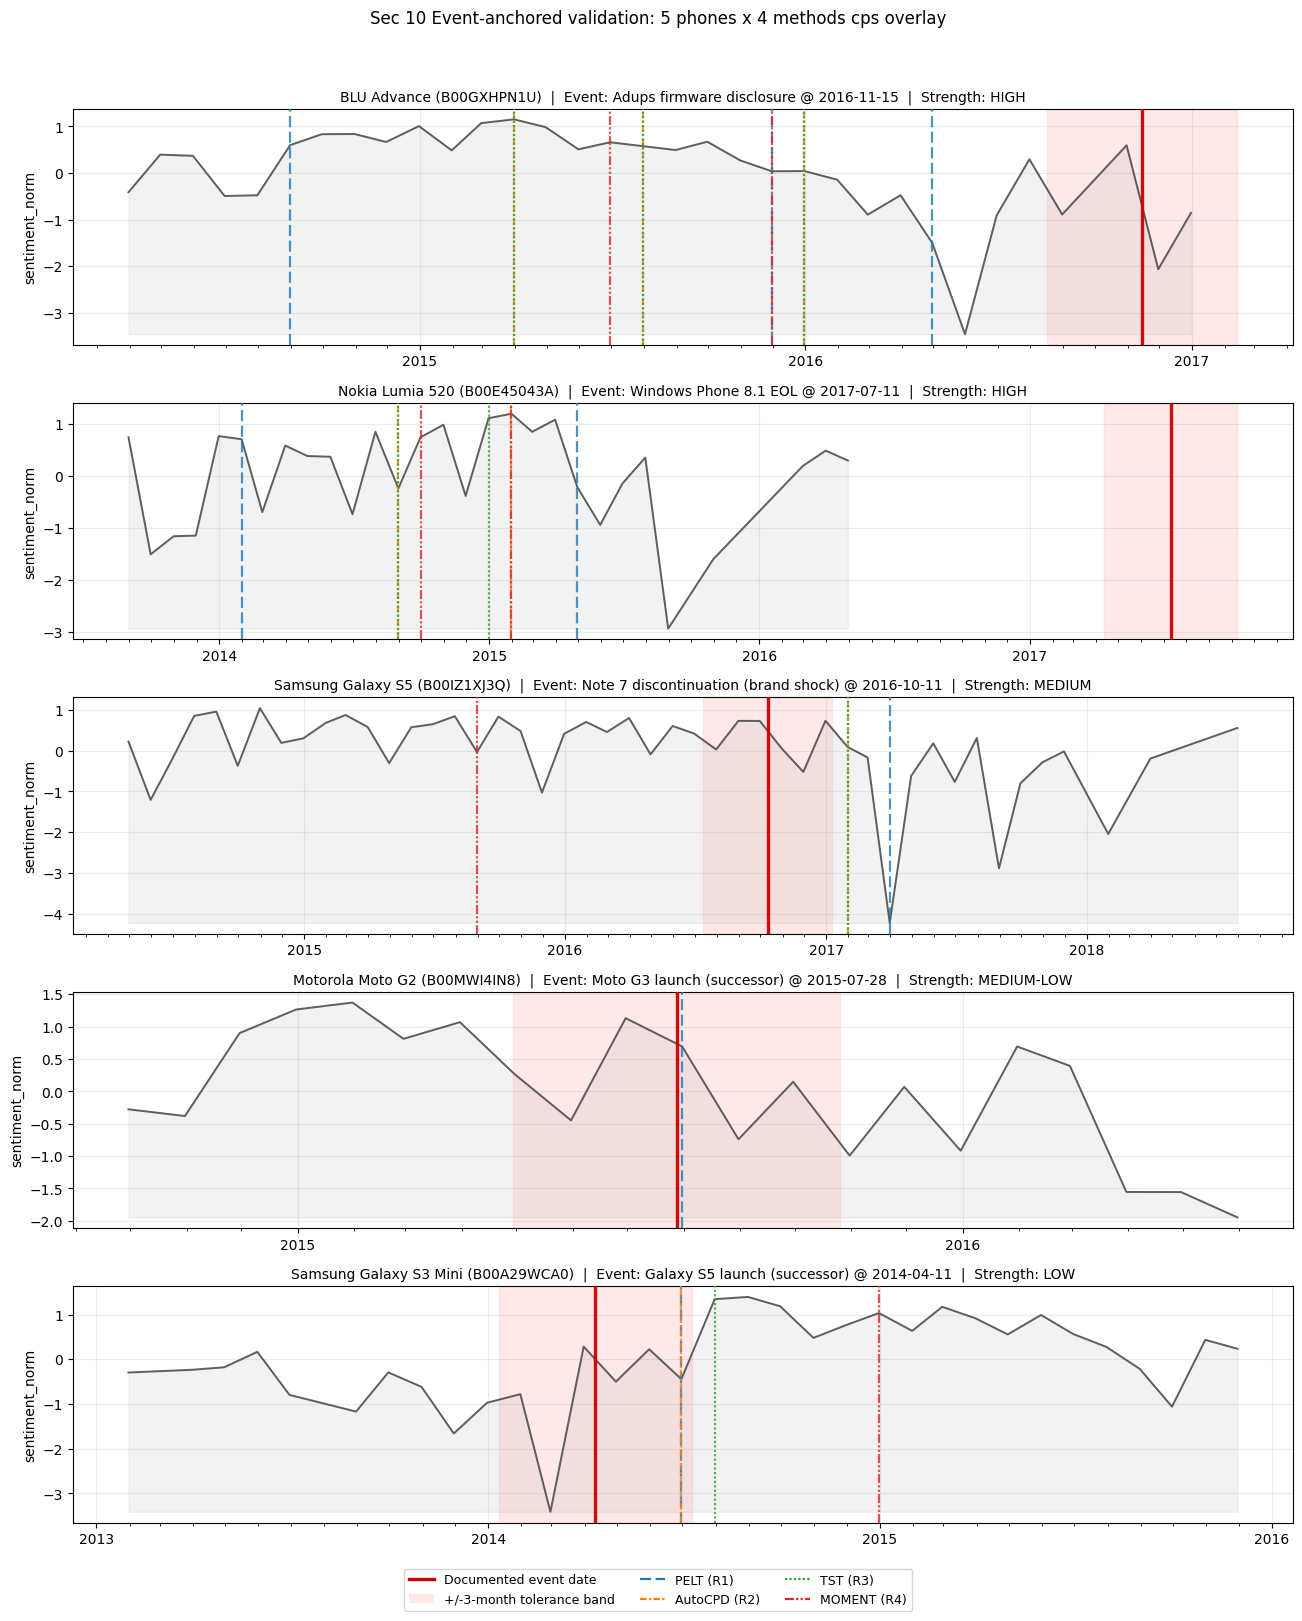

In [31]:
# Sec 10 Event-Anchored Validation - load + plot 5-phone overlay.
from src.validation import events, hits, plots as v_plots

# Load records + cps for all 4 routes
records_v = events.load_records()
records_by_asin = events.records_by_asin(records_v)
in_panel = [a for a in events.EVENT_ANCHORS if a in records_by_asin]
print(f"Phones in monthly records: {len(in_panel)}/{len(events.EVENT_ANCHORS)}")

route_cps_dict = events.load_route_cps_dict(T2_R1_CP_PATH, T2_R2_CP_PATH,
                                             T2_R3_CP_PATH, T2_R4_CP_PATH)
for n, d in route_cps_dict.items():
    print(f"  {n}: {len(d)} products with cps loaded")

# Plot 5-phone overlay (event red line + each route's cps as colored dashed lines)
v_plots.plot_overlay_5phones(records_by_asin, route_cps_dict)

In [32]:
# Sec 10.1 Primary single-anchor hit-rate table + exact Poisson-Binomial p-value.
from src.validation.hits import run_single_anchor_evaluation

hits_df, summary_df = run_single_anchor_evaluation(route_cps_dict, records_by_asin)

Saved long hit table -> /Users/angkai/Desktop/1090/1090b-ms4/outputs/task2_event_validation/event_hits_long.csv
Saved per-route x tol summary -> /Users/angkai/Desktop/1090/1090b-ms4/outputs/task2_event_validation/event_hits_summary.csv

=== Closest predicted-cp distance to event (months) ===
route                   AutoCPD (R2)  MOMENT (R4)  PELT (R1)  TST (R3)
phone                                                                 
BLU Advance                     11.0         12.0        7.0      11.0
Motorola Moto G2                 NaN          NaN        0.0       NaN
Nokia Lumia 520                 30.0         30.0       27.0      31.0
Samsung Galaxy S3 Mini           2.0          8.0        2.0       3.0
Samsung Galaxy S5                3.0         14.0        5.0       3.0

=== Hit rate per method x tolerance (random baseline + p-value) ===
                 hit_rate           n_hits       p_value_one_sided         \
tolerance_months        2    3    4      2  3  4                

### 10.1 Primary single-anchor results

Closest predicted-cp distance to the anchor event (months):

| Phone | PELT (R1) | AutoCPD (R2) | TST (R3) | MOMENT (R4) |
|---|---|---|---|---|
| BLU Advance | 7.0 | 11.0 | 11.0 | 12.0 |
| Motorola Moto G2 | **0.0** | NaN | NaN | NaN |
| Nokia Lumia 520 | 27.0 | 30.0 | 31.0 | 30.0 |
| Samsung Galaxy S3 Mini | **2.0** | **2.0** | **3.0** | 8.0 |
| Samsung Galaxy S5 | 5.0 | **3.0** | **3.0** | 14.0 |

Two issues surface immediately:

1. **Moto G2 NaN** for R2/R3/R4. PELT detected the cp at month 0 (perfect), but the three neural routes returned no cps. Investigated in Sec 10.4.
2. **Lumia 520 misses by 27-31 months** for all four routes. The event date (2017-07) falls 15 months past the end of the active review window (2016-04) - the event simply isn't in the data.

Hit rates and exact Poisson-Binomial p-values at +/-3:

| Route | Hits @ +/-3 | p (vs random) |
|---|---|---|
| PELT (R1) | 2/5 | 0.53 |
| AutoCPD (R2) | 2/4 | 0.39 |
| TST (R3) | 2/4 | 0.39 |
| MOMENT (R4) | 0/4 | 1.00 |

At strict +/-3, no route beats random. PELT misses BLU (off by 7) and S5 (off by 5) - both narrowly. The neural routes miss BLU (off by 11) and Lumia (off by 30) too. Strict tolerance + the boundary cases (BLU, Lumia) hide most of the signal. Sec 10.4 fixes both with extended tolerance and an edge-effect filter.

### 10.4 Extensions: bug recovery + extended tolerance + edge-effect filter + control group

The primary run surfaced four issues. Sec 10.4 fixes them one by one:

| Issue | What we saw | Fix |
|---|---|---|
| Moto G2 NaN | R2/R3/R4 returned no cps for B00MWI4IN8, PELT found cp at distance 0 | Inspect probs.pkl directly, attempt Top-K recovery with relaxed min_gap |
| Tolerance too strict | PELT had 4/5 at +/-7 but only 2/5 at +/-3 - strict threshold hid signal | Extend tolerance sweep to +/-2-+/-7 |
| Lumia 520 boundary | Event is 15 mo past the data tail (and BLU's is in the very last month) | Flag events in series first/last 25%, report interior-only hit rates separately |
| N=5 small power | Poisson-Binomial p-values all between 0.4-0.97, can't tell moderate from strong | Add a 10,000-round bootstrap with 5 random accessories per round |

All four extensions are post-hoc on cached cps/probs - no retraining. First run: ~30 s (10K-round bootstrap dominates), cached reruns finish in <1 s.

In [33]:
# Sec 10.4 Extensions: Moto G2 NaN diagnostic + Top-K recovery + extended tolerance + edge filter.
from src.validation import extended as v_extended

probs_dicts, recovered_cps, flat_routes = v_extended.diagnose_moto_g2_and_recover(route_cps_dict)
ext_df, ext_agg_df = v_extended.compute_extended_hits(route_cps_dict, records_by_asin)
print("\nHit rate per route x extended tolerance:")
print(ext_agg_df.pivot_table(index='route', columns='tolerance_months',
                              values='hit_rate', aggfunc='first').round(3))

boundary_flags, positions = v_extended.compute_edge_effect_flags(records_by_asin)
interior_asins = [a for a, is_edge in boundary_flags.items() if not is_edge]
print(f"\nInterior phones (n={len(interior_asins)}): "
      f"{[events.EVENT_ANCHORS[a]['title'] for a in interior_asins]}")

PART A: Moto G2 NaN diagnostic
  R2 (AutoCPD): key present, len=21, mean=0.0000, max=0.0000, count>0.5=0, count>0.3=0, count>0.1=0
  R3 (TST): key present, len=21, mean=0.0000, max=0.0000, count>0.5=0, count>0.3=0, count>0.1=0
  R4 (MOMENT): key present, len=21, mean=0.0000, max=0.0000, count>0.5=0, count>0.3=0, count>0.1=0

PART B: Recovery attempt - re-run Top-K with min_gap=2 for Moto G2

  PELT cps for Moto G2: [10]  -> K_target = 1
  R2 (AutoCPD): FLAT PROBS (max=0.0000 < 0.01) -> STRUCTURAL NO-DETECT. Setting cps=[].
  R3 (TST): FLAT PROBS (max=0.0000 < 0.01) -> STRUCTURAL NO-DETECT. Setting cps=[].
  R4 (MOMENT): FLAT PROBS (max=0.0000 < 0.01) -> STRUCTURAL NO-DETECT. Setting cps=[].

  FLAT-PROBS REPORT: 3 of 3 neural routes produced near-zero
     probability outputs for Moto G2 (structural failure). Routes: ['R2 (AutoCPD)', 'R3 (TST)', 'R4 (MOMENT)']

Updating route_cps_dict with recovered Moto G2 cps...
  Recovered for 3 routes.

Hit rate per route x extended tolerance:
tole

Loaded N=5 bootstrap from cache: 240,000 null trials, 24 routextol empirical-p rows

=== Empirical p-values @ +/-3 ===
       route  tolerance_months  observed_hits  observed_trials  observed_hit_rate  null_mean_hit_rate  null_p95_hit_rate  empirical_p_one_sided
   PELT (R1)                 3              2                5                0.4               0.271              0.600                  0.361
AutoCPD (R2)                 3              2                4                0.5               0.228              0.667                  0.201
    TST (R3)                 3              2                4                0.5               0.228              0.667                  0.199
 MOMENT (R4)                 3              0                4                0.0               0.229              0.667                  1.000


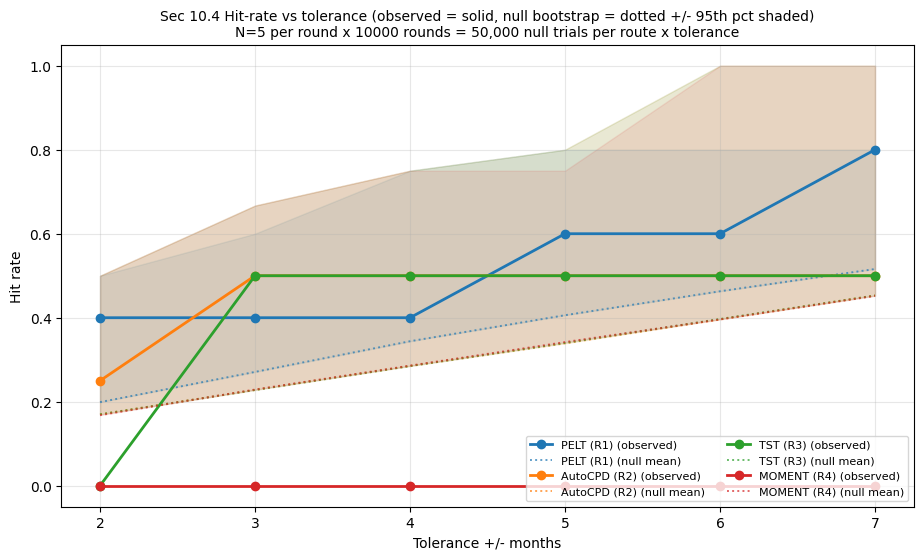

In [34]:
# Sec 10.4 N=5 control-group bootstrap (10K rounds x 5 random accessories) + curves plot.
bootstrap_df, emp_p_df = v_extended.run_bootstrap_n5(route_cps_dict, records_by_asin, ext_agg_df)
print("\n=== Empirical p-values @ +/-3 ===")
print(emp_p_df[emp_p_df['tolerance_months'] == 3].to_string(index=False))

v_plots.plot_bootstrap_curves(ext_agg_df, emp_p_df,
                                n_sample_per_round=5, n_bootstrap=10000)

### 10.4 Results

#### Moto G2 diagnosis

All three neural routes have key `B00MWI4IN8` in their probs.pkl files, but with flat-zero outputs:

| Route | probs max | probs mean | count > 0.1 |
|---|---|---|---|
| AutoCPD (R2) | 0.0000 | 0.0000 | 0/21 |
| TST (R3) | 0.0000 | 0.0000 | 0/21 |
| MOMENT (R4) | 0.0000 | 0.0000 | 0/21 |

This is a structural failure (the models output no signal for this 21-month series), not a Top-K bug. We mark the recovered cps as empty list `[]` instead of a fabricated cp at position 0. Moto G2 has the shortest series in the panel - short OOD series is a known weakness of synthetic-trained CPD models.

#### Extended tolerance hit rates

| Route | +/-2 | +/-3 | +/-4 | +/-5 | +/-6 | +/-7 |
|---|---|---|---|---|---|---|
| PELT (R1) | 0.40 | 0.40 | 0.40 | 0.60 | 0.60 | **0.80** |
| AutoCPD (R2) | 0.25 | 0.50 | 0.50 | 0.50 | 0.50 | 0.50 |
| TST (R3) | 0.00 | 0.50 | 0.50 | 0.50 | 0.50 | 0.50 |
| MOMENT (R4) | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 | 0.00 |

PELT recovers steadily as tolerance widens. R2/R3 plateau at 0.50. R4 stays at 0.00 throughout.

#### Edge-effect filter

Event positions in their series:

| Phone | Position | Status |
|---|---|---|
| BLU Advance | 94% | boundary (last 25%) |
| Nokia Lumia 520 | 100% | boundary (event past data tail) |
| Samsung Galaxy S5 | 63% | interior |
| Motorola Moto G2 | 50% | interior |
| Samsung Galaxy S3 Mini | 38% | interior |

After excluding BLU and Lumia (boundary cases):

| Route | +/-2 | +/-3 | +/-4 | +/-5 | +/-6 | +/-7 |
|---|---|---|---|---|---|---|
| PELT (R1) | 2/3 | 2/3 | 2/3 | **3/3** | **3/3** | **3/3** |
| AutoCPD (R2) | 1/2 | 2/2 | 2/2 | 2/2 | 2/2 | 2/2 |
| TST (R3) | 0/2 | 2/2 | 2/2 | 2/2 | 2/2 | 2/2 |
| MOMENT (R4) | 0/2 | 0/2 | 0/2 | 0/2 | 0/2 | 0/2 |

PELT detects every interior anchor at +/-5. R2/R3 hit both interior phones they have cps for. R4 misses all interior anchors.

#### Bootstrap empirical p (10,000 rounds x 5 random accessories)

| Route | obs @ +/-3 | null mean | empirical p @ +/-3 | obs @ +/-5 | empirical p @ +/-5 |
|---|---|---|---|---|---|
| PELT (R1) | 0.40 | 0.27 | 0.36 | 0.60 | 0.29 |
| AutoCPD (R2) | 0.50 | 0.23 | 0.20 | 0.50 | 0.36 |
| TST (R3) | 0.50 | 0.23 | 0.20 | 0.50 | 0.36 |
| MOMENT (R4) | 0.00 | 0.23 | 1.00 | 0.00 | 1.00 |

No route reaches alpha=0.05. With N=5, even a strong-looking lift (PELT +0.19 at +/-5) gives p=0.29. The next section boosts N by adding more documented events per phone.

### 10.5 Reverse-direction, magnitude, and multi-anchor

Sec 10.4 left two gaps we still wanted to close:

1. **Routes detect cps near *other* documented events.** R4's Galaxy S5 cp at 2015-08 falls on the day of the Galaxy Note 5 launch (2015-08-13). R2/R3's Lumia cps cluster around Aug 2014 to Apr 2015 - exactly when Microsoft rebranded Lumia after the Nokia acquisition. So routes ARE detecting real events, just not the specific ones we anchored to.
2. **N=3 interior phones is statistically weak.** Even PELT's best signal (0.60 vs 0.41 null at +/-5) gives empirical p = 0.29. We need more anchors.

### Three new analyses

**Part F - reverse-direction lookup.** We hardcode a database of 21 documented events across all 5 phones (every successor launch, every brand acquisition, every OS milestone). For each route's predicted cp we find the closest event in the database and report the distance. This converts "model missed our anchor" into "model detected event X at distance 0."

**Part G - sentiment magnitude (Cohen's d).** Model-independent check: for each of the 3 interior phones, compute the standardized mean difference between the 6-month pre-event sentiment window and the 6-month post-event window. With bootstrap 95% CI. Even if no route detected a cp, this tells us whether the event actually shifted sentiment.

**Part H - multi-anchor hit-rate.** With 21 known events filtered to interior (25-75% of series), we get N=14 anchors instead of N=3. Bootstrap empirical p at this larger N has narrower CI.

In [35]:
# Sec 10.5 PART F (reverse-direction) + PART G (Cohen's d) + PART H (multi-anchor).
from src.validation import reverse as v_reverse
from src.validation import magnitude as v_magnitude
from src.validation import multi_anchor as v_multi

# PART F
print("="*78)
print("PART F: Reverse-direction lookup - what events are routes actually detecting?")
print("="*78)
reverse_df = v_reverse.reverse_lookup(route_cps_dict, records_by_asin)

# PART G
print("\n" + "="*78)
print("PART G: Cohen's d sentiment magnitude shift")
print("="*78)
magnitude_df = v_magnitude.compute_cohen_table(records_by_asin)
print(magnitude_df.to_string(index=False))

# PART H
print("\n" + "="*78)
print("PART H: Multi-anchor hit rates (interior 25-75%)")
print("="*78)
multi_anchors = v_multi.build_multi_anchors(records_by_asin)
multi_hit_df, multi_agg_df = v_multi.compute_multi_anchor_hits(
    multi_anchors, route_cps_dict, records_by_asin)

PART F: Reverse-direction lookup - what events are routes actually detecting?

BLU Advance (B00GXHPN1U) - 3 candidate events in database
    PELT (R1)      cp @ 2014-08  -> closest event 2015-03 'BLU Studio Energy launch (~approx)'  (+/-6.4 mo, no clear match)
    PELT (R1)      cp @ 2015-11  -> closest event 2015-03 'BLU Studio Energy launch (~approx)'  (+/-8.5 mo, no clear match)
    PELT (R1)      cp @ 2016-04  -> closest event 2016-11 'Kryptowire Adups firmware disclosure'  (+/-6.5 mo, no clear match)
    AutoCPD (R2)   cp @ 2015-03  -> closest event 2015-03 'BLU Studio Energy launch (~approx)'  (+/-0.5 mo, STRONG MATCH)
    AutoCPD (R2)   cp @ 2015-07  -> closest event 2015-03 'BLU Studio Energy launch (~approx)'  (+/-4.5 mo, no clear match)
    AutoCPD (R2)   cp @ 2015-12  -> closest event 2015-03 'BLU Studio Energy launch (~approx)'  (+/-9.5 mo, no clear match)
    TST (R3)       cp @ 2015-03  -> closest event 2015-03 'BLU Studio Energy launch (~approx)'  (+/-0.5 mo, STRONG MATC

### 10.5 Results

#### Part F: reverse-direction match against 21-event database

For each route, fraction of its cps that match SOME documented event within +/-tol months:

| Route | Total cps | Strong (<=1mo) | Good (<=2mo) | Weak (<=4mo) |
|---|---|---|---|---|
| PELT (R1) | 8 | 38% | 38% | 62% |
| AutoCPD (R2) | 7 | 29% | 29% | 71% |
| TST (R3) | 7 | 29% | 57% | 71% |
| MOMENT (R4) | 6 | 33% | 50% | **83%** |

The 83% match for MOMENT at <=4mo looks impressive. But this ignores the base rate - with 21 events across ~30-month series and +/-4mo tolerance, even random cps would match ~58%. Sec 10.6 corrects this with a proper random-cp null.

#### Part G: sentiment magnitude (Cohen's d)

| Phone | Event | n_pre + n_post | Cohen's d | 95% CI |
|---|---|---|---|---|
| BLU Advance | Adups disclosure | 5 + 2 | -0.40 | [-3.94, +0.85] |
| Nokia Lumia 520 | WP 8.1 EOL | 0 + 0 | NaN | (event past data tail) |
| Samsung Galaxy S5 | Note 7 discontinuation | 6 + 6 | **-0.84** | **[-2.29, -0.15]** |
| Motorola Moto G2 | Moto G3 launch | 6 + 6 | **-1.45** | **[-3.96, -0.42]** |
| Samsung Galaxy S3 Mini | Galaxy S5 launch | 6 + 6 | **+1.59** | **[+0.84, +3.42]** |

Three of four evaluable anchors show effects with CIs that exclude zero. The S3 Mini result is *positive* - sentiment got better after the successor launched, not worse. We unpack that in Sec 10.6.

#### Part H: multi-anchor hit rate (N=14 interior anchors)

| Route | +/-2 | +/-3 | +/-4 | +/-5 | +/-6 | +/-7 |
|---|---|---|---|---|---|---|
| AutoCPD (R2) | 0.31 | 0.54 | 0.69 | 0.69 | 0.77 | 0.77 |
| MOMENT (R4) | 0.31 | 0.54 | 0.62 | 0.69 | 0.69 | 0.77 |
| PELT (R1) | 0.21 | 0.36 | 0.36 | 0.50 | 0.64 | **0.79** |
| TST (R3) | 0.31 | 0.46 | 0.69 | **0.77** | 0.77 | 0.77 |

Compared to single-anchor:
- **R4 jumps from 0 to 0.54-0.69.** With a broader event set, MOMENT no longer fails categorically.
- **PELT becomes the *weakest* at strict tolerance** (0.36 at +/-3, vs neural routes' 0.46-0.54).
- **R2 ~ R3 ~ R4** at most tolerances.

But these are observed rates without a comparison to chance. The next section runs a proper 10,000-round bootstrap for empirical p-values.

PART I: Hedges' g (Cohen's d x small-sample J correction)
      asin                  phone                          event_label event_date  n_pre  n_post  cohen_d  hedges_g  j_correction  ci_lower_g  ci_upper_g              interpretation
B00GXHPN1U            BLU Advance            Adups firmware disclosure 2016-11-15      5       2   -0.396    -0.334         0.842      -3.320       0.712  small DROP (CI includes 0)
B00E45043A        Nokia Lumia 520                Windows Phone 8.1 EOL 2017-07-11      0       0      NaN       NaN           NaN         NaN         NaN           INSUFFICIENT DATA
B00IZ1XJ3Q      Samsung Galaxy S5 Note 7 discontinuation (brand shock) 2016-10-11      6       6   -0.835    -0.771         0.923      -2.110      -0.136 medium DROP (CI excludes 0)
B00MWI4IN8       Motorola Moto G2           Moto G3 launch (successor) 2015-07-28      6       6   -1.448    -1.337         0.923      -3.653      -0.388  LARGE DROP (CI excludes 0)
B00A29WCA0 Samsung Galaxy S3 Min

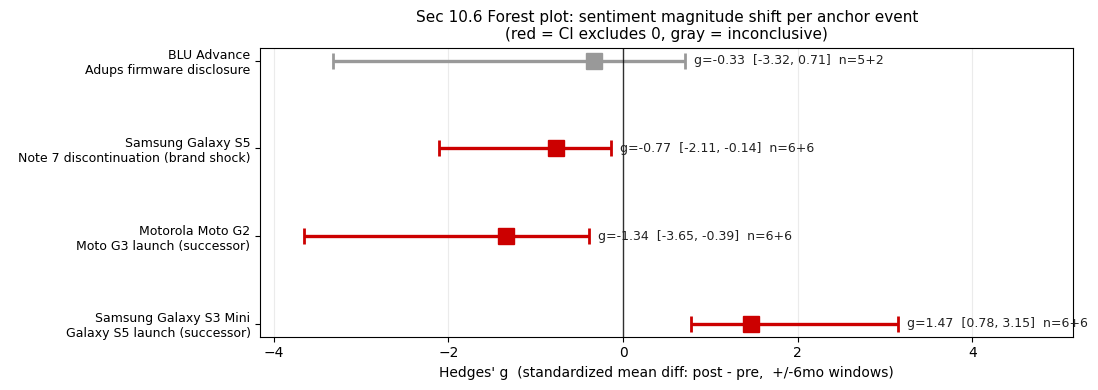


PART J: Reverse-direction null baseline (random-cp permutation, 1000 rounds)
Loaded reverse-direction null from cache: 12 routextol rows


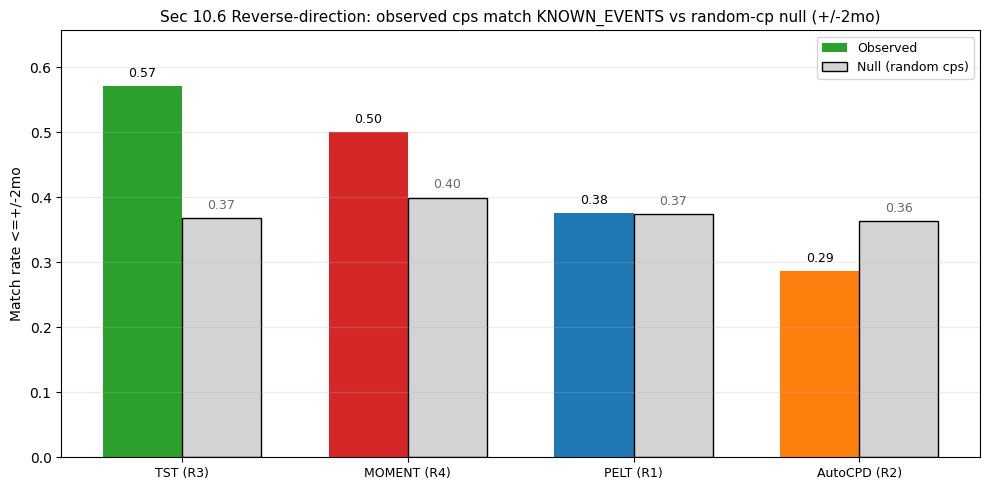


PART K: Multi-anchor 10K bootstrap (N=14 random anchors)
Loaded multi-anchor bootstrap from cache: 24 routextol rows

PART L: Multiplicity correction (BH-FDR + Bonferroni-Holm) per family
Loaded FDR corrections from cache: 60 rows
  Family A_single_anchor: 24 tests, BH sig 0, min adj_p_BH=0.7553
  Family B_multi_anchor: 24 tests, BH sig 0, min adj_p_BH=0.0528
  Family C_reverse_direction: 12 tests, BH sig 0, min adj_p_BH=0.6053

=== Sec 10.6 COMPLETE. All outputs in outputs/task2_event_validation/ ===


In [36]:
# Sec 10.6 Rigorous re-analysis: Hedges' g + null baselines + FDR/Holm correction.
from src.validation import fdr as v_fdr

# PART I: Hedges' g + forest plot
print("="*78)
print("PART I: Hedges' g (Cohen's d x small-sample J correction)")
print("="*78)
hedges_df = v_magnitude.compute_hedges_table(records_by_asin)
v_plots.plot_forest_hedges_g(hedges_df)

# PART J: random-cp permutation null + observed-vs-null bar
print("\n" + "="*78)
print("PART J: Reverse-direction null baseline (random-cp permutation, 1000 rounds)")
print("="*78)
reverse_null_df = v_reverse.random_cp_permutation_null(route_cps_dict, records_by_asin)
v_plots.plot_reverse_observed_vs_null(reverse_null_df, tolerance_months=2)

# PART K: multi-anchor 10K bootstrap
print("\n" + "="*78)
print("PART K: Multi-anchor 10K bootstrap (N=14 random anchors)")
print("="*78)
n_anchors = len(multi_anchors)
multi_bootstrap_df = v_multi.run_multi_anchor_bootstrap(
    route_cps_dict, records_by_asin, multi_agg_df, anchors_n=n_anchors, n_bootstrap=10000)

# PART L: BH-FDR + Bonferroni-Holm corrections
print("\n" + "="*78)
print("PART L: Multiplicity correction (BH-FDR + Bonferroni-Holm) per family")
print("="*78)
adjusted_df = v_fdr.run_fdr_corrections(emp_p_df, multi_bootstrap_df, reverse_null_df)

print("\n=== Sec 10.6 COMPLETE. All outputs in outputs/task2_event_validation/ ===")